# Final Model with Interactions
## Setup 
### Import Python Packages 

In [1]:
# Import external packages
import pandas as pd
import numpy as np

import sys
import pickle
import warnings
from itertools import chain, product
# import random 
# import os

from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_percentage_error

from pygam import GAM, s, te, f, l, utils

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import LogLocator

import optuna
from optuna.visualization import matplotlib as optunampl

# Internal packages 
sys.path.append("../")
from src import utils
from src.gam import training, explain
from src.colours import red_blue

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 260)
warnings.filterwarnings("ignore")

### Set Variables

In [2]:
# Fontsize for visualisation
tick_fontsize = 14
label_fontsize = 18
title_fontsize = 22

# Define utility columns
exposure = "Policies_Exposed"
target = "act_death_rate"
holdout = "holdout"
random_fold = "random_fold"

# Define actual and expected death count columns in the data
act_death = "Death_Count"
exp_death_mi = "ExpDth_VBT2015wMI_Cnt"

# Data
data_version = "_ml"
model_version = "_v3"
data_file = f"export/Modelling_data (Filtered and Grouped by Selected Features){data_version}.parquet"

# Define the modelling logs that record key metrics across the modelling workflow
modelling_log_02 = f"output/02_model_note_single_factor_gam{model_version}.xlsx"
modelling_log_03 = f"output/03_model_note_xgb_interaction_detection{model_version}.xlsx"
modelling_log_04 = f"output/04_model_note_final_gam{model_version}.xlsx"

# Define the names of the single factor GAM model
sf_gam_output = f"output/single_factor_gam{model_version}.pkl"
final_gam_output = f"output/final_gam{model_version}.pkl"

# Define the names of the rating tables that defines the GAM model 
sf_rating_table_output = f"output/single_factor_rating_tables{model_version}.pkl"
final_rating_table_output = f"output/final_rating_tables{model_version}.pkl"

# Deifne the names of the prediction files 
sf_gam_pred_file = f"export/Single Factor Model Predictions{model_version}.parquet"
xgb_gam_pred_file = f"export/XGB Model Predictions{model_version}.parquet"
final_gam_pred_file = f"export/Final Model Predictions{model_version}.parquet"

## Create Modelling Dataframes
### Import Data

In [3]:
model_data = pd.read_parquet(data_file)
model_data

,Observation_Year,Sex,Smoker_Status,Issue_Age,Duration,Face_Amount_Band,Issue_Year,Attained_Age,Death_Count,Policies_Exposed,ExpDth_VBT2015wMI_Cnt,is_test,is_validation,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal,holdout,random_fold,act_death_rate,exp_death_rate_mi
unique_id,,,,,,,,,,,,,,,,,,,,
0,2012,M,NS,34,17,"05: 100,000 - 249,999",1996,50,0.0,1546.786003,2.355224,True,False,1,0,5,1,6,0.000000,0.001523
1,2012,M,NS,34,17,"06: 250,000 - 499,999",1995,50,0.0,792.154739,1.203345,True,False,1,0,6,1,6,0.000000,0.001519
2,2012,M,NS,34,17,"06: 250,000 - 499,999",1996,50,2.0,1031.760315,1.567217,False,False,1,0,6,0,1,0.001938,0.001519
3,2012,M,NS,34,17,"07: 500,000 - 999,999",1995,50,0.0,327.323694,0.497118,False,False,1,0,7,0,5,0.000000,0.001519
4,2012,M,NS,34,17,"07: 500,000 - 999,999",1996,50,0.0,458.157228,0.694401,False,False,1,0,7,0,5,0.000000,0.001516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612760,2019,M,S,76,2,"01: 0 - 9,999",2018,77,0.0,0.882192,0.018247,False,False,1,1,1,0,1,0.000000,0.020683
612761,2019,M,S,76,2,"02: 10,000 - 24,999",2017,77,0.0,0.213699,0.004420,False,False,1,1,2,0,1,0.000000,0.020683
612762,2019,M,S,78,2,"02: 10,000 - 24,999",2017,79,0.0,0.512329,0.012250,False,False,1,1,2,0,2,0.000000,0.023910


In [4]:
###########################################################################
###########################################################################

# Define the list of numerical features
num_feat = [
    "Observation_Year", 
    "Duration", 
    "Attained_Age", 
    "Face_Amount_Band_ordinal",
    # "Issue_Age",
    # "Issue_Year",
]

# Define the list of categorical features
cat_feat = ["Sex_cat_level", "Smoker_Status_cat_level"]

###########################################################################
###########################################################################

# Define the full feature list 
all_feat = num_feat + cat_feat
print(all_feat)

['Observation_Year', 'Duration', 'Attained_Age', 'Face_Amount_Band_ordinal', 'Sex_cat_level', 'Smoker_Status_cat_level']


In [5]:
# Check there is no null value across the board 
model_data.isnull().sum()

Observation_Year            0
Sex                         0
Smoker_Status               0
Issue_Age                   0
Duration                    0
Face_Amount_Band            0
Issue_Year                  0
Attained_Age                0
Death_Count                 0
Policies_Exposed            0
ExpDth_VBT2015wMI_Cnt       0
is_test                     0
is_validation               0
Sex_cat_level               0
Smoker_Status_cat_level     0
Face_Amount_Band_ordinal    0
holdout                     0
random_fold                 0
act_death_rate              0
exp_death_rate_mi           0
dtype: int64

### Define Required Dataframes

In [6]:
# Define the training and holdout dataframes
X_train = model_data.loc[model_data[holdout] == 0, all_feat]
y_train = model_data.loc[model_data[holdout] == 0, target]
w_train = model_data.loc[model_data[holdout] == 0, exposure]

X_test = model_data.loc[model_data[holdout] == 1, all_feat]
y_test = model_data.loc[model_data[holdout] == 1, target]
w_test = model_data.loc[model_data[holdout] == 1, exposure]

# Define the cross-validation folds required for hyperparameter tuning
random_fold_values = model_data.loc[model_data[holdout] == 0, random_fold].values

# Define a list of tuples, each first element contains indices for the training fold and each second element contains indices for the holdout
folds = []
df_ = pd.DataFrame(
    zip(range(len(random_fold_values)), random_fold_values),
    columns=["row_index", random_fold],
)

for i in range(max(random_fold_values)):
    index_train = df_[df_[random_fold] != i + 1]["row_index"].to_list()
    index_valid = df_[df_[random_fold] == i + 1]["row_index"].to_list()
    folds.append((index_train, index_valid))

valid_folds = [k[1] for k in folds]
check = np.sort(np.array(list(chain(*valid_folds)))) == np.arange(len(X_train))

assert check.sum() == len(
    X_train
), "Not all the rows in the training data are included in the data folds."

## Final Model Training
### Define Interaction Terms

In [7]:
###########################################################################
###########################################################################

interaction_tab = "Inter_Imp_GBM"

###########################################################################
###########################################################################

two_way_gain_df = pd.read_excel(modelling_log_03, sheet_name=interaction_tab)
two_way_gain_df[
    two_way_gain_df["Feature_List"].apply(lambda x: "Observation_Year" in x)
]

,Feature_List,Gain1,Gain_Norm
5,Duration x Observation_Year,2620.661371,0.054315
7,Attained_Age x Observation_Year,1945.516753,0.040322
8,Observation_Year x Sex,1265.465039,0.026228
9,Face_Amount_Band_ordinal x Observation_Year,1247.486438,0.025855
13,Observation_Year x Smoker_Status,78.442020,0.001626


Text(0.5, 1.0, 'Interaction Importance')

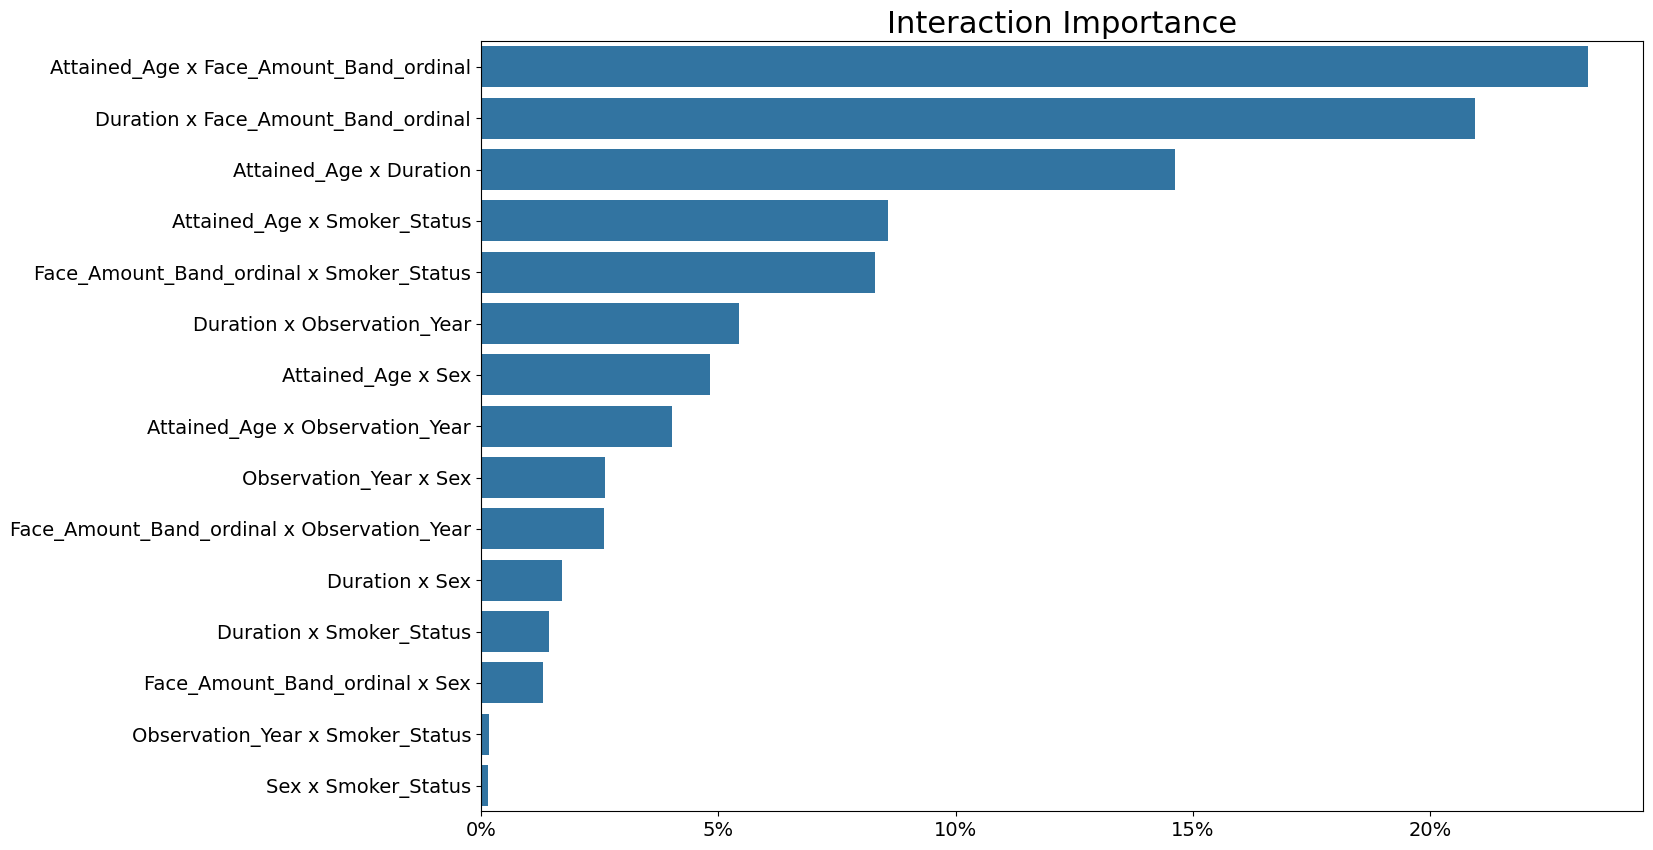

In [8]:
plt.rcParams["figure.figsize"] = (15, 10)
plt.rcParams["axes.edgecolor"] = "black"

fig, ax = plt.subplots(1)

sns.barplot(
    data=two_way_gain_df, 
    y="Feature_List", 
    x="Gain_Norm", 
    color="tab:blue", 
    ax=ax,
)

# Do some formating in the x and y axes to make them easier to read
xticker = ax.get_xticks() 
xlabel = [f'{x:,.0%}' for x in xticker]
ax.set_xticklabels(xlabel, fontsize=tick_fontsize)

ylabel = two_way_gain_df["Feature_List"] 
ax.set_yticklabels(ylabel, fontsize=tick_fontsize)

ax.set_facecolor("white")

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_title("Interaction Importance", fontsize=title_fontsize)

In [9]:
################################################
################################################

# Define a list of interacton terms that makes sense from an underwriting perspective
interaction_list = [
    "Attained_Age x Face_Amount_Band_ordinal",
    "Duration x Face_Amount_Band_ordinal",
    "Attained_Age x Duration",
    "Attained_Age x Smoker_Status",
    "Face_Amount_Band_ordinal x Smoker_Status",
    "Duration x Observation_Year",
    "Attained_Age x Sex",
    "Attained_Age x Observation_Year",
    "Observation_Year x Sex",
]

################################################
################################################

interaction_list = [(x.split(" x ")[0], x.split(" x ")[1]) for x in interaction_list]
interaction_list = [
    (
        x[0] + "_cat_level" if x[0] + "_cat_level" in cat_feat else x[0],
        x[1] + "_cat_level" if x[1] + "_cat_level" in cat_feat else x[1],
    )
    for x in interaction_list
]
print(f"{len(interaction_list)} number of interaction terms: {interaction_list}")

9 number of interaction terms: [('Attained_Age', 'Face_Amount_Band_ordinal'), ('Duration', 'Face_Amount_Band_ordinal'), ('Attained_Age', 'Duration'), ('Attained_Age', 'Smoker_Status_cat_level'), ('Face_Amount_Band_ordinal', 'Smoker_Status_cat_level'), ('Duration', 'Observation_Year'), ('Attained_Age', 'Sex_cat_level'), ('Attained_Age', 'Observation_Year'), ('Observation_Year', 'Sex_cat_level')]


### Define GAM Term Structure

In [10]:
# Create a term string for GAM training
term_string, num_feat_map, cat_feat_map, interact_term_map = (
    training.create_term_structure(
        num_feat,
        cat_feat,
        X_train,
        interaction_term_list=interaction_list,
        # mono_dec_var_list=["Face_Amount_Band_ordinal"],
        mono_inc_var_list=["Duration"],
    )
)
print(term_string)

s(0, lam=lam_num, n_splines=n_splines)+ s(1, lam=lam_num, n_splines=n_splines, constraints='monotonic_inc')+ s(2, lam=lam_num, n_splines=n_splines)+ s(3, lam=lam_num, n_splines=n_splines) + f(4, lam=lam_cat) + f(5, lam=lam_cat) + te(2, 3, lam=[lam_num_inter, lam_num_inter], n_splines=[n_splines_inter, n_splines_inter], constraints=[None, None], dtype=['numerical', 'numerical']) + te(1, 3, lam=[lam_num_inter, lam_num_inter], n_splines=[n_splines_inter, n_splines_inter], constraints=['monotonic_inc', None], dtype=['numerical', 'numerical']) + te(2, 1, lam=[lam_num_inter, lam_num_inter], n_splines=[n_splines_inter, n_splines_inter], constraints=[None, 'monotonic_inc'], dtype=['numerical', 'numerical']) + te(2, 5, lam=[lam_num_inter, lam_cat_inter], n_splines=[n_splines_inter, 4], constraints=[None, None], dtype=['numerical', 'categorical']) + te(3, 5, lam=[lam_num_inter, lam_cat_inter], n_splines=[n_splines_inter, 4], constraints=[None, None], dtype=['numerical', 'categorical']) + te(1, 0

### Hyperparameter Tuning

In [11]:
# Further split training set into training and validation set
X_train_train = model_data.loc[
    (~model_data["is_test"]) & ~(model_data["is_validation"]), all_feat
]
y_train_train = model_data.loc[
    (~model_data["is_test"]) & ~(model_data["is_validation"]), target
]
w_train_train = model_data.loc[
    (~model_data["is_test"]) & ~(model_data["is_validation"]), exposure
]

X_train_valid = model_data.loc[
    (~model_data["is_test"]) & (model_data["is_validation"]), all_feat
]
y_train_valid = model_data.loc[
    (~model_data["is_test"]) & (model_data["is_validation"]), target
]
w_train_valid = model_data.loc[
    (~model_data["is_test"]) & (model_data["is_validation"]), exposure
]

In [12]:
# Create study
study = optuna.create_study(direction="minimize")

# Define objective
objective = training.OptunaGamObjective(
    term_string,
    (8, 14), # Need to experiment with the range 
    (1, 1e2, True), 
    (1, 1e2, True),
    X_train_train, 
    X_train_valid, 
    y_train_train, 
    y_train_valid,
    w_train_train, 
    w_train_valid, 
    n_splines_inter_range=(6, 8),
    lam_num_inter_range=(1, 1e2, False),
    lam_cat_inter_range=(1, 1e2, False),
)

[I 2026-01-31 01:22:09,307] A new study created in memory with name: no-name-e232d9ae-c0ab-4e01-87d2-77507e3c2e5a


In [13]:
###########################################################################
###########################################################################

n_trials = 50

###########################################################################
###########################################################################

# Do study
study.optimize(objective, n_trials=n_trials)

[I 2026-01-31 01:27:18,984] Trial 0 finished with value: 51145.016974865735 and parameters: {'n_splines': 9, 'lam_num': 6.467853604090784, 'lam_cat': 83.72058643319053, 'n_splines_inter': 6, 'lam_num_inter': 74.09819703423737, 'lam_cat_inter': 23.044646453130657}. Best is trial 0 with value: 51145.016974865735.
[I 2026-01-31 01:33:38,996] Trial 1 finished with value: 51077.21804028108 and parameters: {'n_splines': 14, 'lam_num': 6.643290758412701, 'lam_cat': 1.861910223255812, 'n_splines_inter': 7, 'lam_num_inter': 76.92342753226556, 'lam_cat_inter': 88.21146447124586}. Best is trial 1 with value: 51077.21804028108.
[I 2026-01-31 01:38:04,274] Trial 2 finished with value: 51102.64319943763 and parameters: {'n_splines': 8, 'lam_num': 1.9718176880353862, 'lam_cat': 3.6564814155748735, 'n_splines_inter': 6, 'lam_num_inter': 29.80869539795131, 'lam_cat_inter': 40.516907923778305}. Best is trial 1 with value: 51077.21804028108.
[I 2026-01-31 01:46:23,576] Trial 3 finished with value: 51024.

In [14]:
# Print best trial
best_trial_number = study.best_trial.number
best_trial_value = study.best_trial.value
print(f"Best trial: {best_trial_number} with value {best_trial_value}\n{'*'*80}")

# Print out the best parameters
best_hyperparams = study.best_params
print(best_hyperparams)

Best trial: 45 with value 50877.036110862304
********************************************************************************
{'n_splines': 11, 'lam_num': 1.966855842401076, 'lam_cat': 3.8815229684788255, 'n_splines_inter': 8, 'lam_num_inter': 1.2629407494560996, 'lam_cat_inter': 18.070258944024424}


In [15]:
# Save the tuning progress
with pd.ExcelWriter(
    f"{modelling_log_04}", engine="openpyxl"
) as writer:
    study.trials_dataframe().sort_values("value").to_excel(
        writer, sheet_name="Final_Tune", index=False
    )

In [ ]:
plt.figure()
plt.rcParams["figure.figsize"] = [10, 5]
optunampl.plot_optimization_history(study)

plt.figure()
plt.rcParams["figure.figsize"] = [10, 5]
optunampl.plot_param_importances(study)

plt.figure()
plt.rcParams["figure.figsize"] = [10, 5]
optunampl.plot_edf(study)

In [ ]:
param_importance = optuna.importance.get_param_importances(study)

plt.figure()
plt.rcParams["figure.figsize"] = [20, 8]
optunampl.plot_parallel_coordinate(study, params=list(param_importance)[:3])

plt.figure()
plt.rcParams["figure.figsize"] = [20, 8]
optunampl.plot_contour(study, params=list(param_importance)[:3])

plt.figure()
plt.rcParams["figure.figsize"] = [20, 8]
optunampl.plot_slice(study, params=list(param_importance)[:3])

### Model Training

In [14]:
###########################################################################
###########################################################################

hp_sf_tab = "Final_Tune"

###########################################################################
###########################################################################

study_df = pd.read_excel(f"{modelling_log_04}", hp_sf_tab)
best_params = study_df.sort_values("value").filter(regex="params_").iloc[0].to_dict()
best_params = {k.replace("params_", ""): v for k, v in best_params.items()}

n_splines = int(best_params["n_splines"])
lam_num = best_params["lam_num"]
lam_cat = best_params["lam_cat"]
n_splines_inter = int(best_params["n_splines_inter"])

# As a heuristic, set hyperparameters related to interactions to be the same as single factor's
lam_num_inter = best_params["lam_num_inter"]
lam_cat_inter = best_params["lam_cat_inter"]

print(f"{'n_splines':<18}: {n_splines}")
print(f"{'lam_num':<18}: {lam_num}")
print(f"{'lam_cat':<18}: {lam_cat}")
print(f"{'n_splines_inter':<18}: {n_splines_inter}")
print(f"{'lam_num_inter':<18}: {lam_num_inter}")
print(f"{'lam_cat_inter':<18}: {lam_cat_inter}")

n_splines         : 11
lam_num           : 1.966855842401076
lam_cat           : 3.881522968478825
n_splines_inter   : 8
lam_num_inter     : 1.2629407494561
lam_cat_inter     : 18.07025894402442


In [15]:
# Fit the GAM model
gam_final = GAM(
    eval(term_string),
    distribution="poisson",
    link="log",
).fit(X_train, y_train, weights=w_train)

gam_final.summary()

GAM                                                                                                       
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                    113.8751
Link Function:                          LogLink Log Likelihood:                                       -inf
Number of Samples:                       490212 AIC:                                                   inf
                                                AICc:                                                  inf
                                                UBRE:                                               2.5203
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                    0.874
Feature Function                  Lam

In [16]:
# Save the GAM model as a pickle file
with open(final_gam_output, "wb") as file:
    pickle.dump(gam_final, file)

### Derive Relativities

In [17]:
# Re-load the GAM model
with open(final_gam_output, "rb") as file:
    gam_final = pickle.load(file)

print(gam_final.summary())

GAM                                                                                                       
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                    113.8751
Link Function:                          LogLink Log Likelihood:                                       -inf
Number of Samples:                       490212 AIC:                                                   inf
                                                AICc:                                                  inf
                                                UBRE:                                               2.5203
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                    0.874
Feature Function                  Lam

In [18]:
# Initialise an empty list to save the multiplier applied to the intercept
intercept_adj_list = []
# Get the intercept of GAM
intercept = np.exp(gam_final.coef_[-1])
print(f"GAM Intercept: {intercept:.2%}")

# Define a list of all variables used in the model
all_feat = list(num_feat_map.values()) + list(cat_feat_map.values())
number_factors = len(all_feat)

GAM Intercept: 1.59%


#### Numerical Variables

In [19]:
# Initilise an empty dictionary for numerical variables
num_rel_dict = {}

for k, v in num_feat_map.items():
    
    # Get the unique levels associated with a numerical variable
    index = np.sort(X_train[v].unique())

    assert (
        np.unique(np.diff(index))[0] == 1 and len(np.unique(np.diff(index))) == 1
    ), "There are probably missing levels in the numerical range. Please check!!"

    # Initialise a 0-array as an input to calculate partial dependency
    t = np.zeros((len(index), number_factors))

    # Get the column index of the numerical variable
    z = X_train.columns.tolist().index(v)

    # Populate the column related to the variable for which we seek partial dependency
    t[:, z] = index

    # Need to use an internal function from PyGAM to get the partial dependence
    modelmat = gam_final.terms.build_columns(t, term=k)
    partial_dependence = np.exp(gam_final._linear_predictor(modelmat=modelmat, term=k))

    # Concatenate the feature values and PDs
    prediction = pd.DataFrame(zip(index, partial_dependence), columns=[v, "pred"])

    # Adjust the PDs such that its weighted average level is 1
    prediction["relativity"] = prediction["pred"].copy()
    prediction = prediction.join(
        X_train.join(w_train).groupby(v)[[exposure]].sum(), on=v
    )
    prediction["rel_weight"] = prediction["relativity"] * prediction[exposure]
    avg_rel = prediction["rel_weight"].sum() / prediction[exposure].sum()
    prediction["relativity"] /= avg_rel

    # Record the multiplier (this needs to be applied to intercept)
    intercept_adj_list.append(avg_rel)
    num_rel_dict[v] = prediction[[v, "relativity", exposure]]

#### Categorical Variables

In [20]:
###########################################################################
###########################################################################

# Define the directory for the categorical mapping spreadsheet
cat_map_table = "export/SOA Categorical Mapping.xlsx"
# Get the mapping tables in the form of a dictionary
cat_map_dict = pd.read_excel(cat_map_table, sheet_name=None)

###########################################################################
###########################################################################

# Initilise an empty dictionary for numerical variables
cat_rel_dict = {}

for k, v in cat_feat_map.items(): 
    
    # Define the clean variable name
    v_clean = v.replace("_cat_level", "")

    # Get the unique levels associated with a categorical variable
    index = np.sort(X_train[v].unique())

    assert (
        np.unique(np.diff(index))[0] == 1 and len(np.unique(np.diff(index))) == 1
    ), "There are probably missing levels in the categorical range. Please check!!"

    # Initialise a 0-array as an input to calculate partial dependency
    t = np.zeros((len(index), number_factors))

    # Get the column index of the numerical variable
    z = X_train.columns.tolist().index(v)

    # Populate the column related to the variable for which we seek partial dependency
    t[:, z] = index

    # Need to use an internal function from PyGAM to get the partial dependence
    modelmat = gam_final.terms.build_columns(t, term=k)
    partial_dependence = np.exp(gam_final._linear_predictor(modelmat=modelmat, term=k))

    # Concatenate the feature values and PDs
    prediction = pd.DataFrame(zip(index, partial_dependence), columns=[v, "pred"])

    # Adjust the PDs such that its weighted average level is 1
    prediction["relativity"] = prediction["pred"].copy()
    prediction = prediction.join(X_train.join(w_train).groupby(v)[[exposure]].sum(), on=v)
    prediction["rel_weight"] = prediction["relativity"] * prediction[exposure]
    avg_rel = prediction["rel_weight"].sum() / prediction[exposure].sum()
    prediction["relativity"] /= avg_rel

    # Get the categorical levels
    table = cat_map_dict[v_clean]
    prediction[v_clean] = prediction[v].map(
        table.set_index("Integer_Value")["Categorical_Level"].to_dict()
    )

    # Record the multiplier (this needs to be applied to intercept)
    intercept_adj_list.append(avg_rel)
    cat_rel_dict[v] = prediction[[v, v_clean, "relativity", exposure]]

#### Interaction Terms

In [21]:
inter_rel_dict = {}

vars_in_interaction = list(interact_term_map.values())
vars_in_interaction = set(list(chain(*vars_in_interaction)))
full_vars = set(list(num_feat_map.values()) + list(cat_feat_map.values()))

for k, v in interact_term_map.items():

    v1, v2 = v
    interaction_name = v1 + " x " + v2

    index1 = np.sort(X_train[v1].unique())
    index2 = np.sort(X_train[v2].unique())
    v1_clean = v1 if v1 in num_feat_map.values() else v1.replace("_cat_level", "")
    v2_clean = v2 if v2 in num_feat_map.values() else v2.replace("_cat_level", "")

    output = list(product(index1, index2))
    output = np.array(sorted(output, key=lambda x: (x[0], x[1])))

    # Initialise a 0-array as an input to calculate partial dependency
    t = np.zeros((output.shape[0], number_factors))
    z1 = X_train.columns.tolist().index(v1)
    z2 = X_train.columns.tolist().index(v2)

    # Populate the column related to the variable for which we seek partial dependency
    t[:, z1] = output[:, 0]
    t[:, z2] = output[:, 1]

    modelmat = gam_final.terms.build_columns(t, term=k)
    partial_dependence = np.exp(gam_final._linear_predictor(modelmat=modelmat, term=k))

    # Concatenate the feature values and PDs
    prediction = pd.DataFrame(
        np.hstack((output, partial_dependence.reshape(-1, 1))), columns=[v1, v2, "pred"]
    )
    # Adjust the PDs such that its weighted average level is 1
    prediction["relativity"] = prediction["pred"].copy()
    prediction = prediction.join(
        X_train.join(w_train).groupby([v1, v2])[[exposure]].sum(), on=[v1, v2]
    )
    prediction[exposure] = prediction[exposure].fillna(0)
    prediction["rel_weight"] = prediction["relativity"] * prediction[exposure]
    avg_rel = prediction["rel_weight"].sum() / prediction[exposure].sum()
    prediction["relativity"] /= avg_rel
    intercept_adj_list.append(avg_rel)

    # Get the categorical levels
    if v1 in cat_feat_map.values(): 
        table = cat_map_dict[v1_clean]
        prediction[v1_clean] = prediction[v1].map(
            table.set_index("Integer_Value")["Categorical_Level"].to_dict()
        )
    if v2 in cat_feat_map.values(): 
        table = cat_map_dict[v2_clean]
        prediction[v2_clean] = prediction[v2].map(
            table.set_index("Integer_Value")["Categorical_Level"].to_dict()
        )
    col_list = [v1, v2, "relativity", exposure]
    if v1 in cat_feat_map.values(): 
        col_list = col_list + [v1_clean]
    if v2 in cat_feat_map.values(): 
        col_list = col_list + [v2_clean]

    inter_rel_dict[interaction_name] = prediction[col_list]

#### Adjust Intercept Term

In [22]:
assert len(intercept_adj_list) == len(
    all_feat + interaction_list
), "# intercept multipliers is not equal to # terms in GAM. Please check!!"

# Perform the adjustment
intercept_final = intercept * np.prod(intercept_adj_list) 

utils.pretty_print("Intercept Values")
print(f"{'Original':<10}: {intercept:,.5%}")
print(f"{'Adjusted':<10}: {intercept_final:,.5%}")

----------------
Intercept Values
----------------
Original  : 1.58786%
Adjusted  : 0.13382%


#### Export Intercept and Relativities

In [23]:
# Define the output
rating_tables = (intercept_final, num_rel_dict, cat_rel_dict, inter_rel_dict)
# Save
with open(final_rating_table_output, "wb") as file:
    pickle.dump(rating_tables, file)

#### Control Testing

In [24]:
# Re-load the rating table outputs
with open(final_rating_table_output, "rb") as file:
    intercept_final, num_rel_dict, cat_rel_dict, inter_rel_dict = pickle.load(file)

# Define a dataframe that contains predictions, target and weight
ypred_test = gam_final.predict(X_test)

ypred_test_df = pd.DataFrame(
    ypred_test, columns=["ypred_final_death_rate"], index=X_test.index
)
ypred_test_df = (
    ypred_test_df.join(y_test)
    .join(w_test)
    .join(
        model_data[
            [
                "Death_Count",
                "ExpDth_VBT2015wMI_Cnt",
                "exp_death_rate_mi",
            ]
        ]
    )
)
ypred_test_df["ypred_final_death_count"] = (
    ypred_test_df["ypred_final_death_rate"] * ypred_test_df[exposure]
)
ypred_test_df

,ypred_final_death_rate,act_death_rate,Policies_Exposed,Death_Count,ExpDth_VBT2015wMI_Cnt,exp_death_rate_mi,ypred_final_death_count
unique_id,,,,,,,
0,0.001818,0.000000,1546.786003,0.0,2.355224,0.001523,2.811542
1,0.001450,0.000000,792.154739,0.0,1.203345,0.001519,1.148945
13,0.002134,0.003392,1179.246857,4.0,1.975629,0.001675,2.516205
18,0.001492,0.000000,273.829023,0.0,0.455744,0.001664,0.408600
20,0.003910,0.000000,19.578894,0.0,0.037323,0.001906,0.076563
...,...,...,...,...,...,...,...
612730,0.041925,0.000000,0.515068,0.0,0.007706,0.014962,0.021594
612741,0.190964,0.000000,0.668493,0.0,0.059190,0.088542,0.127658
612748,0.068874,0.000000,0.657534,0.0,0.026175,0.039807,0.045287


In [25]:
###############################################################
###############################################################

# Define the number of decimal places to round the predictions
rounding_num = 7

###############################################################
###############################################################

# Test on the training ata
ypred_train = gam_final.predict(X_train)

# Define a procedure to score a dataset using the relativities extracted
X_train_rel = X_train.copy()
rel_list = []

for v, r in num_rel_dict.items():
    X_train_rel[v + "_rel"] = X_train_rel[v].map(r.set_index(v)["relativity"].to_dict())
    rel_list.append(v + "_rel")

for v, r in cat_rel_dict.items():
    X_train_rel[v.replace("_cat_level", "") + "_rel"] = X_train_rel[v].map(
        r.set_index(v)["relativity"].to_dict()
    )
    rel_list.append(v.replace("_cat_level", "") + "_rel")

for v, r in inter_rel_dict.items():
    v1, v2 = v.split(" x ")
    v1_clean = v1.replace("_cat_level", "")
    v2_clean = v2.replace("_cat_level", "")
    ineraction_name = v1_clean + "_x_" + v2_clean + "_rel"
    r.rename(columns={"relativity": ineraction_name}, inplace=True)

    X_train_rel = X_train_rel.merge(
        r[[v1, v2, ineraction_name]], on=[v1, v2], how="left"
    )
    rel_list.append(ineraction_name)

# Need to reassign index
X_train_rel.index = X_train.index

In [26]:
# Check there are no null values
assert (
    X_train_rel.isnull().sum().sum() == 0
), "There are NA values in relativities calculated. Please check!!"

ypred_train_df = pd.DataFrame(
    ypred_train, columns=["ypred_final_death_rate"], index=X_train.index
)

ypred_train_df["ypred_final_death_rate_rel"] = (
    X_train_rel[rel_list].prod(axis=1) * intercept_final
)

check_df = ypred_train_df[
    ypred_train_df["ypred_final_death_rate"].round(rounding_num)
    != ypred_train_df["ypred_final_death_rate_rel"].round(rounding_num)
]

# Check if there is any diff between the predictions from model and the predictions from rating tables
assert (
    len(check_df) == 0
), "There are differences detected between the model predictions and the predictions from rating tables. Please check!!"

In [27]:
# Need an augmented X_test as Observation_Year and Duration need to be set as the max observaed values in the training data
X_test2 = X_test.copy()
X_test2["Observation_Year"] = np.where(
    X_test["Observation_Year"] > X_train["Observation_Year"].max(),
    X_train["Observation_Year"].max(),
    X_test["Observation_Year"],
)
X_test2["Duration"] = np.where(
    X_test["Duration"] > X_train["Duration"].max(),
    X_train["Duration"].max(),
    X_test["Duration"],
)
X_test2

,Observation_Year,Duration,Attained_Age,Face_Amount_Band_ordinal,Sex_cat_level,Smoker_Status_cat_level
unique_id,,,,,,
0,2012,17,50,5,1,0
1,2012,17,50,6,1,0
13,2012,18,51,5,1,0
18,2012,18,51,7,1,0
20,2012,19,52,1,1,0
...,...,...,...,...,...,...
612730,2019,2,73,1,1,1
612741,2019,14,85,5,1,1
612748,2019,5,77,2,1,1


In [28]:
# Define a procedure to score a dataset using the relativities extracted
X_test2_rel = X_test2.copy()
rel_list = []

for v, r in num_rel_dict.items():
    X_test2_rel[v + "_rel"] = X_test2_rel[v].map(r.set_index(v)["relativity"].to_dict())
    rel_list.append(v + "_rel")

for v, r in cat_rel_dict.items():
    X_test2_rel[v.replace("_cat_level", "") + "_rel"] = X_test2_rel[v].map(
        r.set_index(v)["relativity"].to_dict()
    )
    rel_list.append(v.replace("_cat_level", "") + "_rel")

for v, r in inter_rel_dict.items():
    v1, v2 = v.split(" x ")
    v1_clean = v1.replace("_cat_level", "")
    v2_clean = v2.replace("_cat_level", "")
    ineraction_name = v1_clean + "_x_" + v2_clean + "_rel"
    r.rename(columns={"relativity": ineraction_name}, inplace=True)

    X_test2_rel = X_test2_rel.merge(
        r[[v1, v2, ineraction_name]], on=[v1, v2], how="left"
    )
    rel_list.append(ineraction_name)

# Need to reassign index
X_test2_rel.index = X_test.index

# Check there is no null values
X_test2_rel.isnull().sum()

Observation_Year                                0
Duration                                        0
Attained_Age                                    0
Face_Amount_Band_ordinal                        0
Sex_cat_level                                   0
Smoker_Status_cat_level                         0
Observation_Year_rel                            0
Duration_rel                                    0
Attained_Age_rel                                0
Face_Amount_Band_ordinal_rel                    0
Sex_rel                                         0
Smoker_Status_rel                               0
Attained_Age_x_Face_Amount_Band_ordinal_rel     0
Duration_x_Face_Amount_Band_ordinal_rel         0
Attained_Age_x_Duration_rel                     0
Attained_Age_x_Smoker_Status_rel                0
Face_Amount_Band_ordinal_x_Smoker_Status_rel    0
Duration_x_Observation_Year_rel                 0
Attained_Age_x_Sex_rel                          0
Attained_Age_x_Observation_Year_rel             0


In [29]:
ypred_test_df["ypred_final_death_rate_rel"] = (
    X_test2_rel[rel_list].prod(axis=1) * intercept_final
)
ypred_test_df["ypred_final_death_count_rel"] = (
    ypred_test_df["ypred_final_death_rate_rel"] * ypred_test_df[exposure]
)
ypred_test_df["ratio_diff"] = (
    ypred_test_df["ypred_final_death_count_rel"] / ypred_test_df["ypred_final_death_count"]
).round(rounding_num)
ypred_test_df

,ypred_final_death_rate,act_death_rate,Policies_Exposed,Death_Count,ExpDth_VBT2015wMI_Cnt,exp_death_rate_mi,ypred_final_death_count,ypred_final_death_rate_rel,ypred_final_death_count_rel,ratio_diff
unique_id,,,,,,,,,,
0,0.001818,0.000000,1546.786003,0.0,2.355224,0.001523,2.811542,0.001818,2.811542,1.0
1,0.001450,0.000000,792.154739,0.0,1.203345,0.001519,1.148945,0.001450,1.148945,1.0
13,0.002134,0.003392,1179.246857,4.0,1.975629,0.001675,2.516205,0.002134,2.516205,1.0
18,0.001492,0.000000,273.829023,0.0,0.455744,0.001664,0.408600,0.001492,0.408600,1.0
20,0.003910,0.000000,19.578894,0.0,0.037323,0.001906,0.076563,0.003910,0.076563,1.0
...,...,...,...,...,...,...,...,...,...,...
612730,0.041925,0.000000,0.515068,0.0,0.007706,0.014962,0.021594,0.041925,0.021594,1.0
612741,0.190964,0.000000,0.668493,0.0,0.059190,0.088542,0.127658,0.190964,0.127658,1.0
612748,0.068874,0.000000,0.657534,0.0,0.026175,0.039807,0.045287,0.068874,0.045287,1.0


In [30]:
ypred_test_df[ypred_test_df["ratio_diff"] != 1]

,ypred_final_death_rate,act_death_rate,Policies_Exposed,Death_Count,ExpDth_VBT2015wMI_Cnt,exp_death_rate_mi,ypred_final_death_count,ypred_final_death_rate_rel,ypred_final_death_count_rel,ratio_diff
unique_id,,,,,,,,,,


### Holdout Assessment

In [31]:
ypred_sf_df = pd.read_parquet(sf_gam_pred_file)
ypred_xgb_df = pd.read_parquet(xgb_gam_pred_file)

# Left join the single-factor GAM predictions onto the ypred dataframe
ypred_test_df = ypred_test_df.join(
    ypred_sf_df[["ypred_death_count", "ypred_death_rate_rel", "ypred_death_count_rel"]]
).join(ypred_xgb_df[["ypred_xgb_death_count", "ypred_xgb_death_rate"]])
ypred_test_df["ypred_death_rate"] = (
    ypred_test_df["ypred_death_count"] / ypred_test_df[exposure]
)

In [32]:
ypred_test_df

,ypred_final_death_rate,act_death_rate,Policies_Exposed,Death_Count,ExpDth_VBT2015wMI_Cnt,exp_death_rate_mi,ypred_final_death_count,ypred_final_death_rate_rel,ypred_final_death_count_rel,ratio_diff,ypred_death_count,ypred_death_rate_rel,ypred_death_count_rel,ypred_xgb_death_count,ypred_xgb_death_rate,ypred_death_rate
unique_id,,,,,,,,,,,,,,,,
0,0.001818,0.000000,1546.786003,0.0,2.355224,0.001523,2.811542,0.001818,2.811542,1.0,2.614666,0.001690,2.614666,2.831225,0.001830,0.001690
1,0.001450,0.000000,792.154739,0.0,1.203345,0.001519,1.148945,0.001450,1.148945,1.0,1.082971,0.001367,1.082971,1.179231,0.001489,0.001367
13,0.002134,0.003392,1179.246857,4.0,1.975629,0.001675,2.516205,0.002134,2.516205,1.0,2.177574,0.001847,2.177574,2.558209,0.002169,0.001847
18,0.001492,0.000000,273.829023,0.0,0.455744,0.001664,0.408600,0.001492,0.408600,1.0,0.364773,0.001332,0.364773,0.440149,0.001607,0.001332
20,0.003910,0.000000,19.578894,0.0,0.037323,0.001906,0.076563,0.003910,0.076563,1.0,0.073376,0.003748,0.073376,0.061959,0.003165,0.003748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612730,0.041925,0.000000,0.515068,0.0,0.007706,0.014962,0.021594,0.041925,0.021594,1.0,0.015819,0.030713,0.015819,0.029875,0.058002,0.030713
612741,0.190964,0.000000,0.668493,0.0,0.059190,0.088542,0.127658,0.190964,0.127658,1.0,0.094377,0.141179,0.094377,0.141389,0.211504,0.141179
612748,0.068874,0.000000,0.657534,0.0,0.026175,0.039807,0.045287,0.068874,0.045287,1.0,0.054563,0.082982,0.054563,0.040277,0.061255,0.082982


In [33]:
# Poisson Deviance
gam_dev = utils.total_poisson_dev(
    y=ypred_test_df["Death_Count"],
    y_pred=ypred_test_df["ypred_death_count"],
)
rel_dev = utils.total_poisson_dev(
    y=ypred_test_df["Death_Count"],
    y_pred=ypred_test_df["ypred_death_count_rel"],
)

gam_final_dev = utils.total_poisson_dev(
    y=ypred_test_df["Death_Count"],
    y_pred=ypred_test_df["ypred_final_death_count"],
)
rel_final_dev = utils.total_poisson_dev(
    y=ypred_test_df["Death_Count"],
    y_pred=ypred_test_df["ypred_final_death_count_rel"],
)
exp_mi_dev = utils.total_poisson_dev(
    y=ypred_test_df["Death_Count"],
    y_pred=ypred_test_df["ExpDth_VBT2015wMI_Cnt"],
)
xgb_dev = utils.total_poisson_dev(
    y=ypred_test_df["Death_Count"],
    y_pred=ypred_test_df["ypred_xgb_death_count"],
)

utils.pretty_print("Total Poisson Deviance")
print(f"{'GAM Single Factor Model':<25}: {gam_dev:,.0f}")
print(f"{'GAM Single Factor Rel':<25}: {rel_dev:,.0f}")
print(f"{'GAM Final Model':<25}: {gam_final_dev:,.0f}")
print(f"{'GAM Final Rel':<25}: {rel_final_dev:,.0f}")
print(f"{'GAM Single Factor + XGB':<25}: {xgb_dev:,.0f}")
print(f"{'SOA Expected (with MI)':<25}: {exp_mi_dev:,.0f}")

----------------------
Total Poisson Deviance
----------------------
GAM Single Factor Model  : 65,105
GAM Single Factor Rel    : 65,105
GAM Final Model          : 64,166
GAM Final Rel            : 64,166
GAM Single Factor + XGB  : 63,942
SOA Expected (with MI)   : 70,844


[Text(0.5, 0, 'exp_death_rate_mi'),
 Text(1.5, 0, 'ypred_death_rate'),
 Text(2.5, 0, 'ypred_xgb_death_rate'),
 Text(3.5, 0, 'ypred_final_death_rate')]

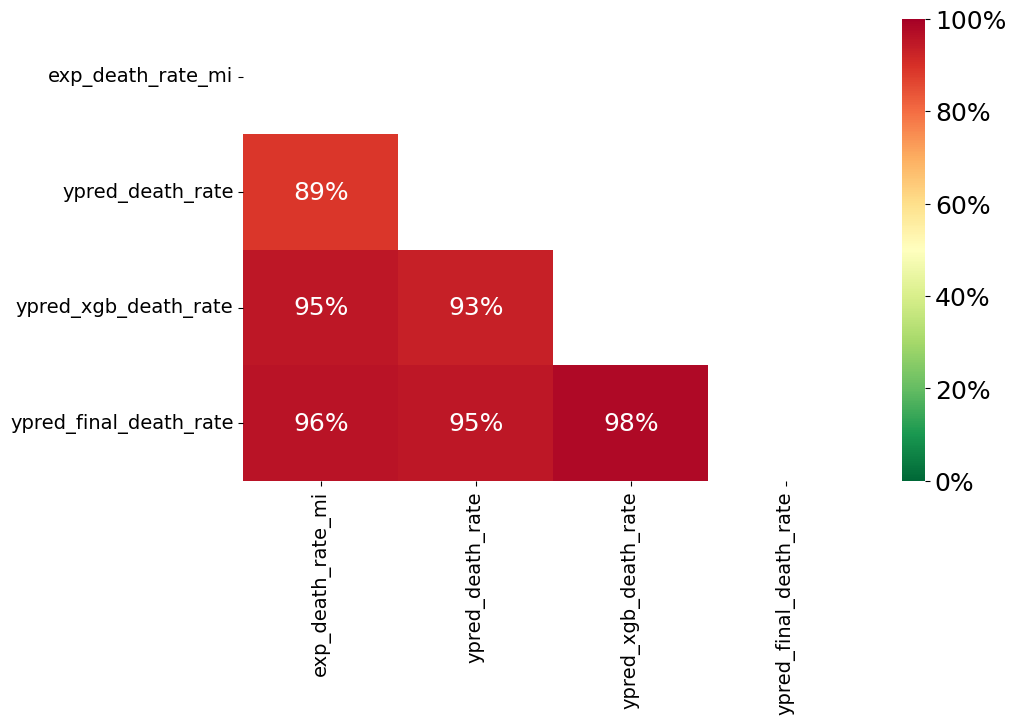

In [34]:
################################################################
################################################################

rate_col = [
    "exp_death_rate_mi",
    "ypred_death_rate",
    "ypred_xgb_death_rate",
    "ypred_final_death_rate",
    
]

################################################################
################################################################

corr_mat = round(ypred_test_df[rate_col].corr(), 2)

# Fill diagonal and upper half with NaNs
mask = np.zeros_like(corr_mat, dtype=bool)
mask[np.triu_indices_from(mask)] = True
corr_mat[mask] = np.nan

fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.heatmap(
    corr_mat,
    annot=True,
    annot_kws={"size": label_fontsize},
    fmt=".0%",
    vmin=0,
    vmax=1,
    cmap="RdYlGn_r",
)

colorbar = ax.collections[0].colorbar 
colorbar.ax.tick_params(labelsize=label_fontsize) 
colorbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))

ax.set_facecolor("white")
ax.set_yticklabels(rate_col, fontsize=tick_fontsize)
ax.set_xticklabels(rate_col, fontsize=tick_fontsize)

In [35]:
################################################################
################################################################

# Define the list of new to current model prediction column names
predict = ["ypred_final_death_count", "ypred_death_count"]

################################################################
################################################################

d = utils.DoubleLift(
    ypred_test_df, predict, "Death_Count", exposure, [0.01, 0.95], approx_num_band=25
)

mape_gam = mean_absolute_percentage_error(
    d.double_lift_table["Death_Count"],
    d.double_lift_table[predict[0]],
    sample_weight=d.double_lift_table[exposure],
)
mape_expected = mean_absolute_percentage_error(
    d.double_lift_table["Death_Count"],
    d.double_lift_table[predict[1]],
    sample_weight=d.double_lift_table[exposure],
)
print(f"{'MAPE - GAM Final':<30}: {mape_gam:.2%}")
print(f"{'MAPE - GAM Single Factor':<30}: {mape_expected:.2%}")

d.double_lift_table.head()

MAPE - GAM Final              : 2.38%
MAPE - GAM Single Factor      : 10.46%


,ratio_band,Death_Count,ypred_final_death_count,ypred_death_count,Policies_Exposed
band,,,,,
1,<= 0.55,0.000113,0.000149,0.000293,88215.739075
2,"(0.55, 0.6]",0.000208,0.000302,0.000522,105981.285681
3,"(0.6, 0.65]",0.000344,0.000300,0.000479,174252.753545
4,"(0.65, 0.7]",0.000350,0.000336,0.000496,325950.896669
5,"(0.7, 0.75]",0.000456,0.000418,0.000574,596890.299657


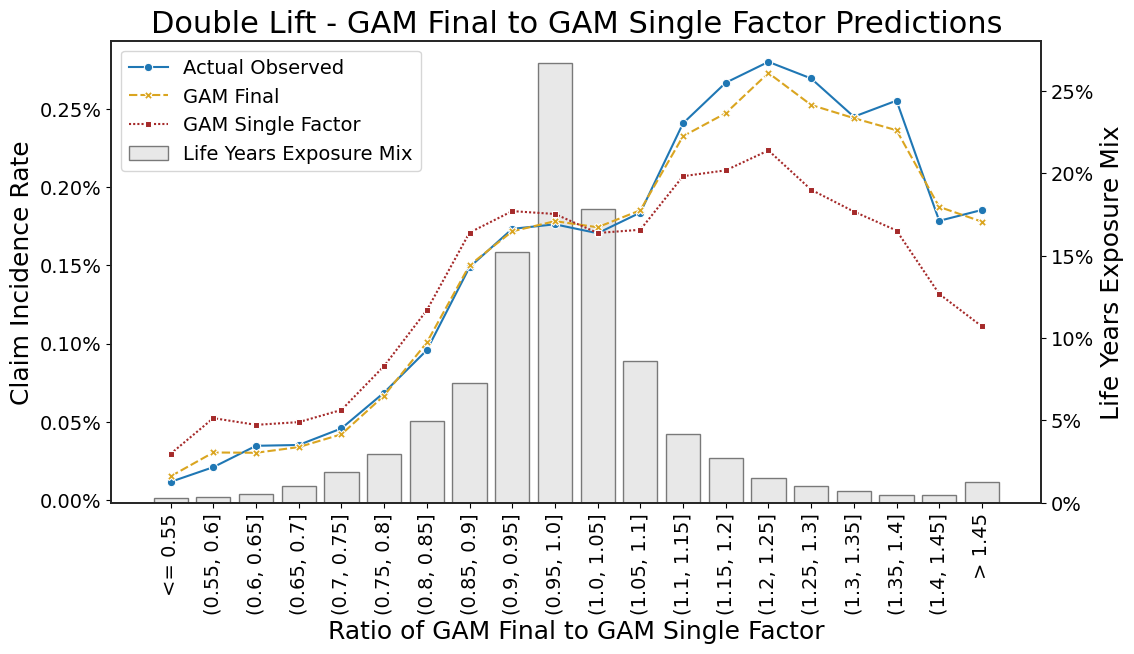

In [36]:
###########################################################################
###########################################################################

param_dict = {
    "title": "Double Lift - GAM Final to GAM Single Factor Predictions", 
    "leftylabel": "Claim Incidence Rate", 
    "rightylabel": "Life Years Exposure Mix",
    "target_legend": "Actual Observed", 
    "new_model_legend": "GAM Final",
    "baseline_legend": "GAM Single Factor",
    "palette": ["tab:blue", "#DAA520", "#A52A2A"]
}

###########################################################################
###########################################################################

plt.rcParams["axes.edgecolor"] = "0.15"
plt.rcParams["axes.linewidth"] = 1.25

fig, ax = plt.subplots(figsize=(12, 6))

d.plot_double_lift(ax=ax, **param_dict)

In [37]:
################################################################
################################################################

# Define the list of new to current model prediction column names
predict = ["ypred_final_death_count", "ExpDth_VBT2015wMI_Cnt"]

################################################################
################################################################

d = utils.DoubleLift(
    ypred_test_df, predict, "Death_Count", exposure, [0.01, 0.95], approx_num_band=25
)

mape_gam = mean_absolute_percentage_error(
    d.double_lift_table["Death_Count"],
    d.double_lift_table[predict[0]],
    sample_weight=d.double_lift_table[exposure],
)
mape_expected = mean_absolute_percentage_error(
    d.double_lift_table["Death_Count"],
    d.double_lift_table[predict[1]],
    sample_weight=d.double_lift_table[exposure],
)
print(f"{'MAPE - GAM Final':<30}: {mape_gam:.2%}")
print(f"{'MAPE - SOA Expected (with MI)':<30}: {mape_expected:.2%}")

d.double_lift_table.head()

MAPE - GAM Final              : 1.01%
MAPE - SOA Expected (with MI) : 24.04%


,ratio_band,Death_Count,ypred_final_death_count,ExpDth_VBT2015wMI_Cnt,Policies_Exposed
band,,,,,
1,<= 0.75,0.001060,0.001066,0.001530,5.359214e+06
2,"(0.75, 0.9]",0.001553,0.001556,0.001891,1.020955e+07
3,"(0.9, 1.05]",0.001886,0.001900,0.001976,6.633587e+06
4,"(1.05, 1.2]",0.001544,0.001532,0.001376,3.724879e+06
5,"(1.2, 1.35]",0.001573,0.001596,0.001257,1.606798e+06


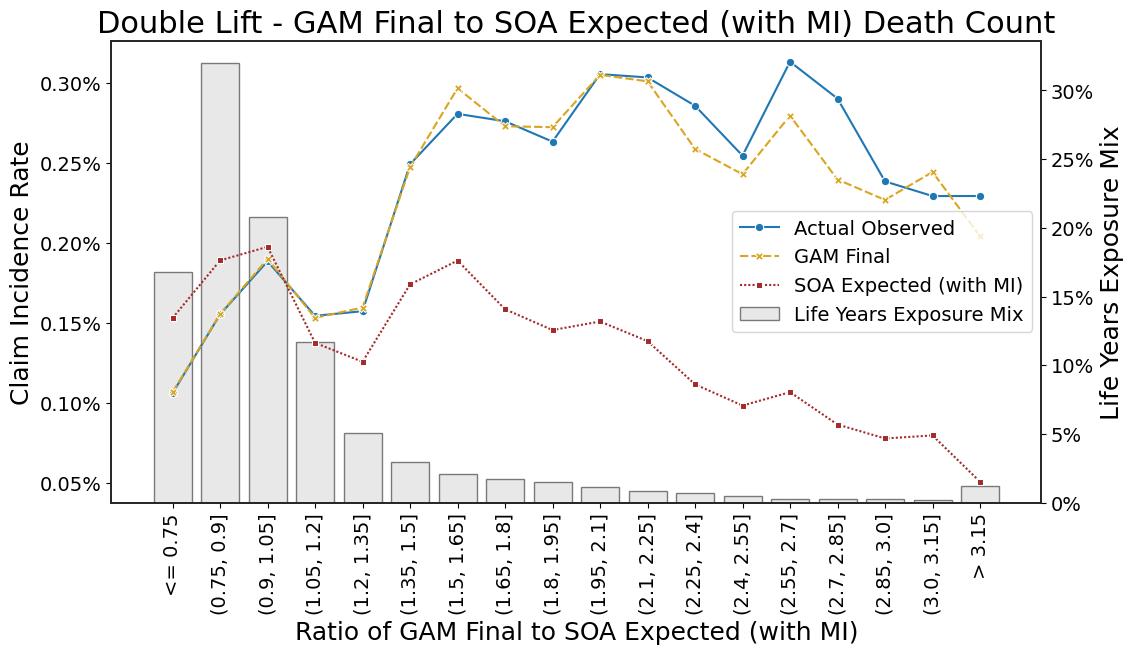

In [38]:
###########################################################################
###########################################################################

param_dict = {
    "title": "Double Lift - GAM Final to SOA Expected (with MI) Death Count", 
    "leftylabel": "Claim Incidence Rate", 
    "rightylabel": "Life Years Exposure Mix",
    "target_legend": "Actual Observed", 
    "new_model_legend": "GAM Final",
    "baseline_legend": "SOA Expected (with MI)",
    "palette": ["tab:blue", "#DAA520", "#A52A2A"]
}

###########################################################################
###########################################################################

plt.rcParams["axes.edgecolor"] = "0.15"
plt.rcParams["axes.linewidth"] = 1.25

fig, ax = plt.subplots(figsize=(12, 6))

d.plot_double_lift(ax=ax, **param_dict)

## Model Explanation 
### Factor Strength

In [39]:
inter_rel_dict2 = inter_rel_dict.copy()

for k, v in inter_rel_dict2.items():
    v1 = k.split(" x ")[0]
    v2 = k.split(" x ")[1]
    v1_clean = v1.replace("_cat_level", "")
    v2_clean = v2.replace("_cat_level", "")

    inter_rel_dict2[v1 + " x " + v2] = inter_rel_dict2[v1 + " x " + v2].rename(
        columns={v1_clean + "_x_" + v2_clean + "_rel": "relativity"}
    )

single_fact_df, interaction_df = explain.factor_strength(
    num_rel_dict,
    cat_rel_dict,
    inter_rel_dict=inter_rel_dict2,
    weight=exposure,
)

In [40]:
# Update the interaction terms to string formats
interaction_df["interaction1"] = interaction_df.apply(
    lambda x: x.feature1 + " x " + x.feature2, axis=1
)
interaction_df["feature1_full"] = interaction_df.apply(
    lambda x: (
        x.feature1 if x.feature1_type == "numerical" else x.feature1 + "_cat_level"
    ),
    axis=1,
)
interaction_df["feature2_full"] = interaction_df.apply(
    lambda x: (
        x.feature2 if x.feature1_type == "numerical" else x.feature2 + "_cat_level"
    ),
    axis=1,
)
interaction_df["interaction2"] = interaction_df.apply(
    lambda x: x.feature1_full + " x " + x.feature2_full, axis=1
)
interaction_df

,interaction_term,feature1,feature2,feature1_type,feature2_type,factor_strength,interaction1,feature1_full,feature2_full,interaction2
0,"(Attained_Age, Face_Amount_Band_ordinal)",Attained_Age,Face_Amount_Band_ordinal,numerical,numerical,0.188046,Attained_Age x Face_Amount_Band_ordinal,Attained_Age,Face_Amount_Band_ordinal,Attained_Age x Face_Amount_Band_ordinal
1,"(Duration, Face_Amount_Band_ordinal)",Duration,Face_Amount_Band_ordinal,numerical,numerical,0.182124,Duration x Face_Amount_Band_ordinal,Duration,Face_Amount_Band_ordinal,Duration x Face_Amount_Band_ordinal
2,"(Attained_Age, Duration)",Attained_Age,Duration,numerical,numerical,0.133237,Attained_Age x Duration,Attained_Age,Duration,Attained_Age x Duration
3,"(Attained_Age, Observation_Year)",Attained_Age,Observation_Year,numerical,numerical,0.108432,Attained_Age x Observation_Year,Attained_Age,Observation_Year,Attained_Age x Observation_Year
4,"(Attained_Age, Smoker_Status)",Attained_Age,Smoker_Status,numerical,categorical,0.083776,Attained_Age x Smoker_Status,Attained_Age,Smoker_Status,Attained_Age x Smoker_Status
5,"(Attained_Age, Sex)",Attained_Age,Sex,numerical,categorical,0.062540,Attained_Age x Sex,Attained_Age,Sex,Attained_Age x Sex
6,"(Face_Amount_Band_ordinal, Smoker_Status)",Face_Amount_Band_ordinal,Smoker_Status,numerical,categorical,0.058366,Face_Amount_Band_ordinal x Smoker_Status,Face_Amount_Band_ordinal,Smoker_Status,Face_Amount_Band_ordinal x Smoker_Status
7,"(Duration, Observation_Year)",Duration,Observation_Year,numerical,numerical,0.038381,Duration x Observation_Year,Duration,Observation_Year,Duration x Observation_Year
8,"(Observation_Year, Sex)",Observation_Year,Sex,numerical,categorical,0.025699,Observation_Year x Sex,Observation_Year,Sex,Observation_Year x Sex


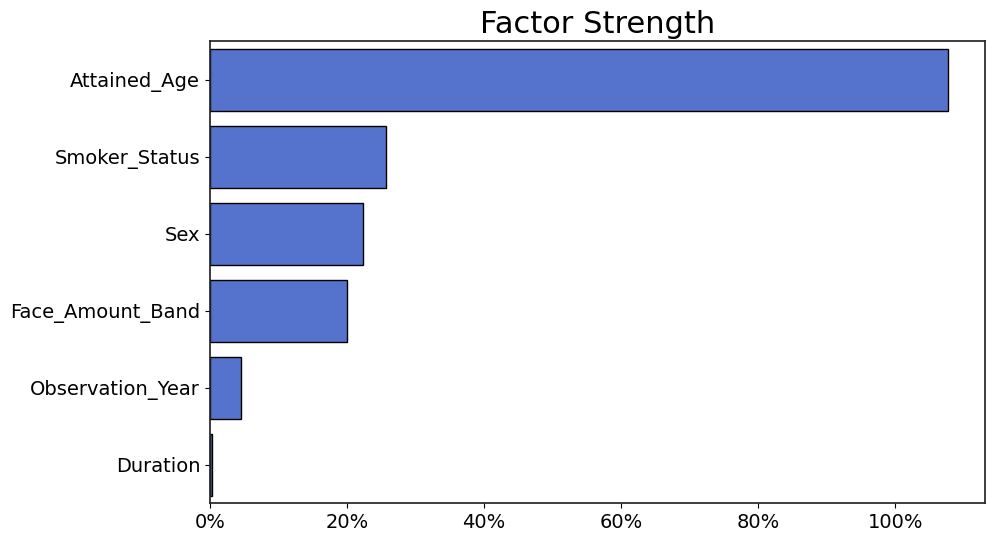

In [41]:
plt.rcParams["figure.figsize"] = [10, 6]
fig, ax = plt.subplots(1)
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.25

plot_df = single_fact_df.copy()
plot_df["feature"] = plot_df["feature"].str.replace("_ordinal", "")

# Plot data
sns.barplot(
    x="factor_strength",
    y="feature",
    data=plot_df,
    ax=ax,
    color="royalblue",
    edgecolor="black",
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.0%}"))
ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)
ax.set_title(f"Factor Strength", fontsize=title_fontsize)
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)

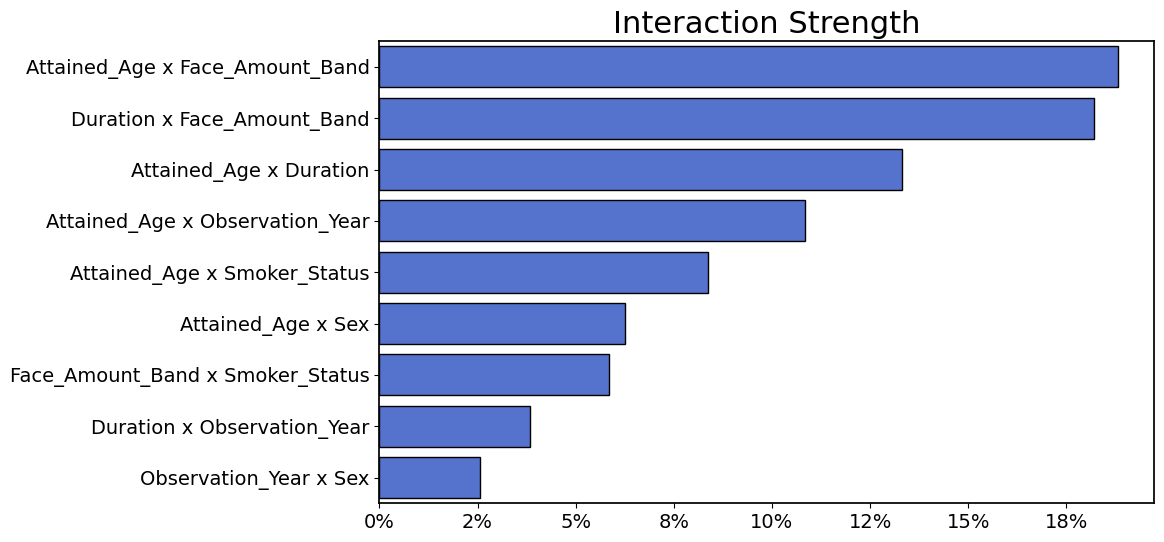

In [42]:
plt.rcParams["figure.figsize"] = [10, 6]
fig, ax = plt.subplots(1)
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.25

plot_df = interaction_df.copy()
plot_df["interaction1"] = plot_df["interaction1"].str.replace("_ordinal", "")

# Plot data
sns.barplot(
    x="factor_strength",
    y="interaction1",
    data=plot_df,
    ax=ax,
    color="royalblue",
    edgecolor="black",
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.0%}"))
ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)
ax.set_title(f"Interaction Strength", fontsize=title_fontsize)
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)

### Single Factor Trends

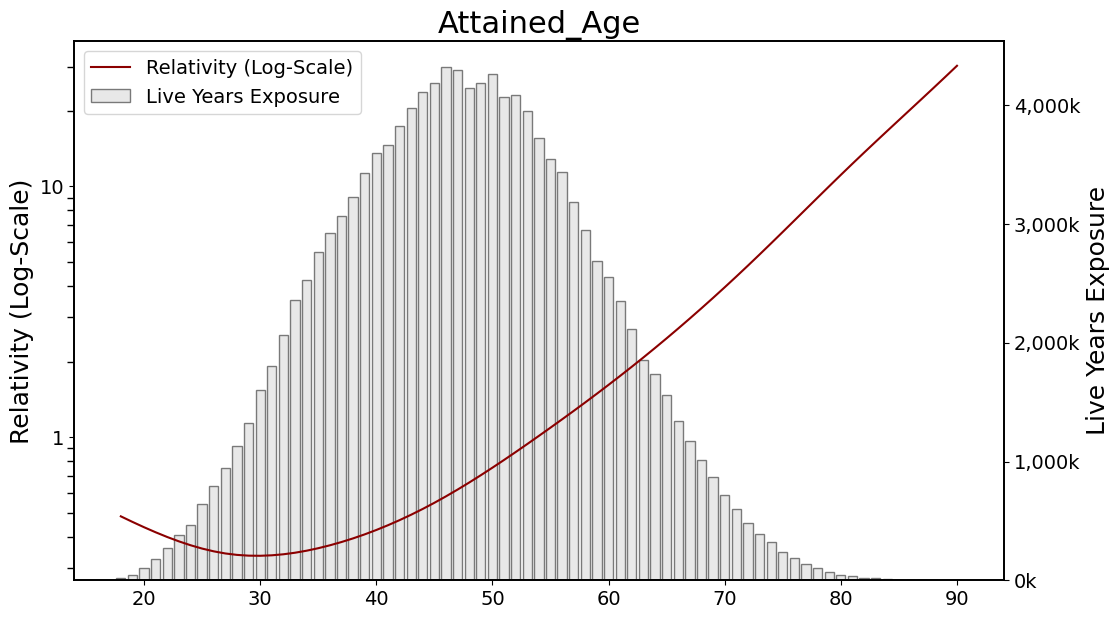

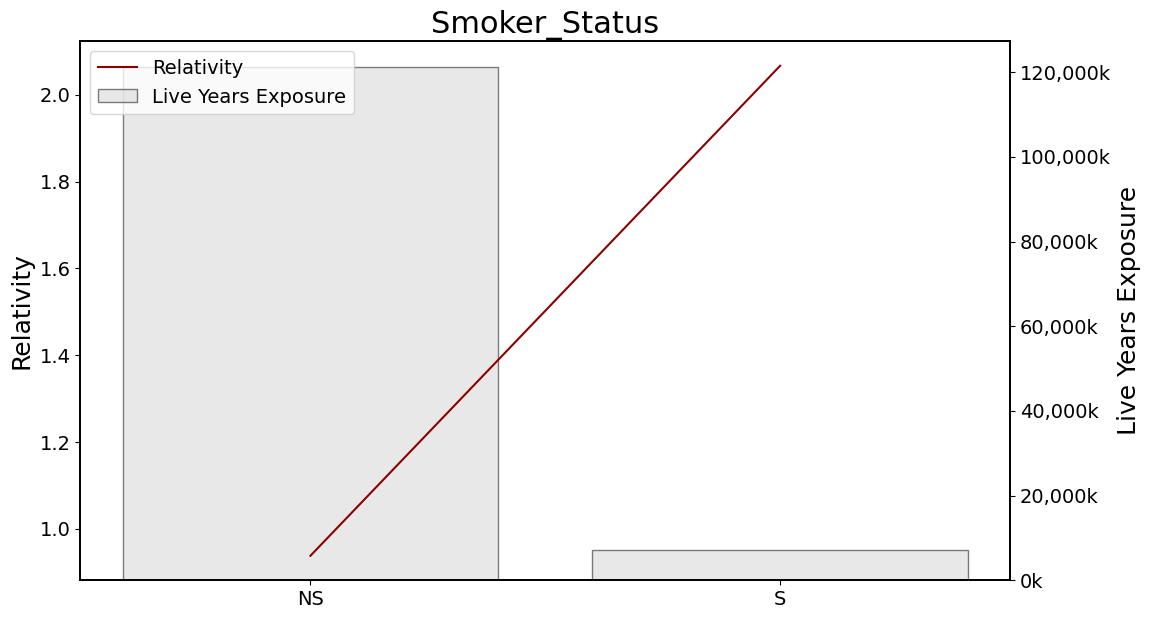

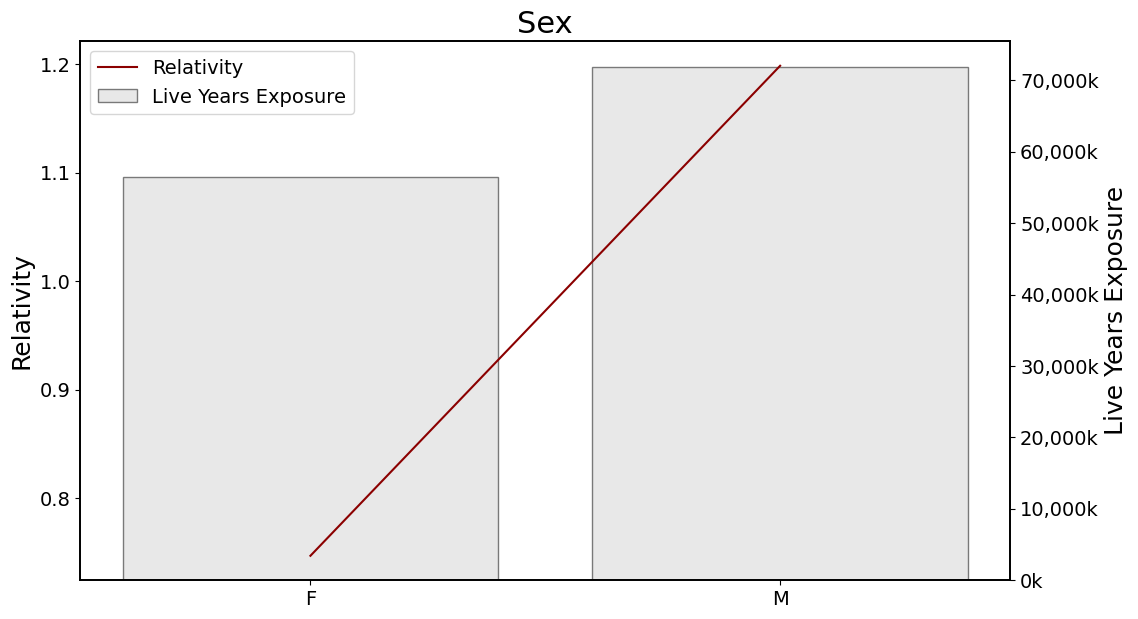

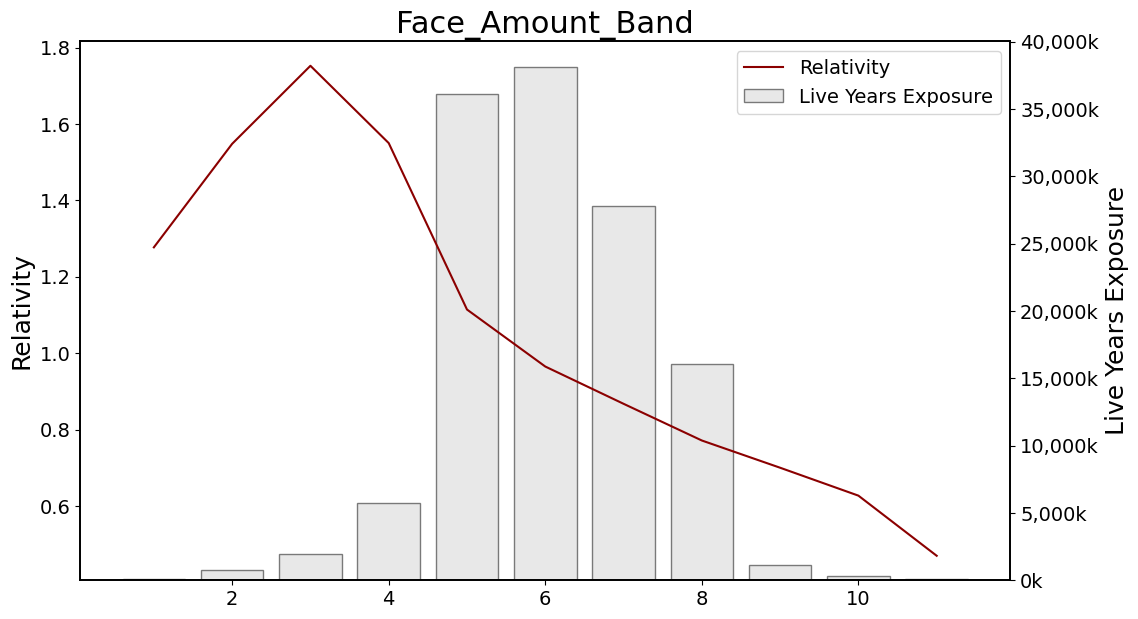

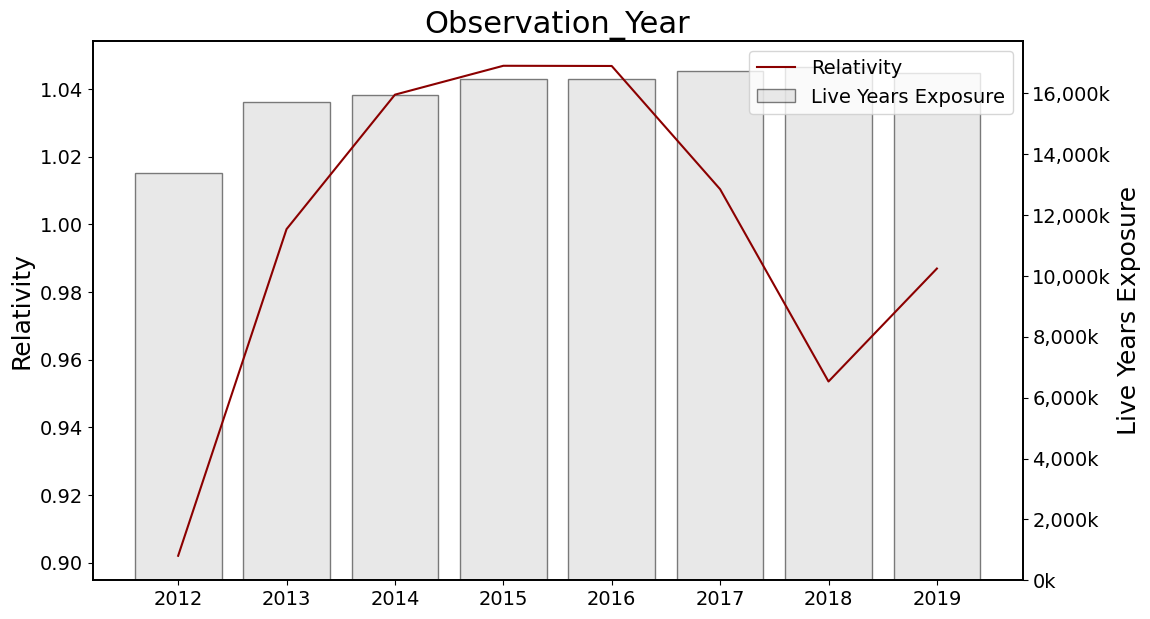

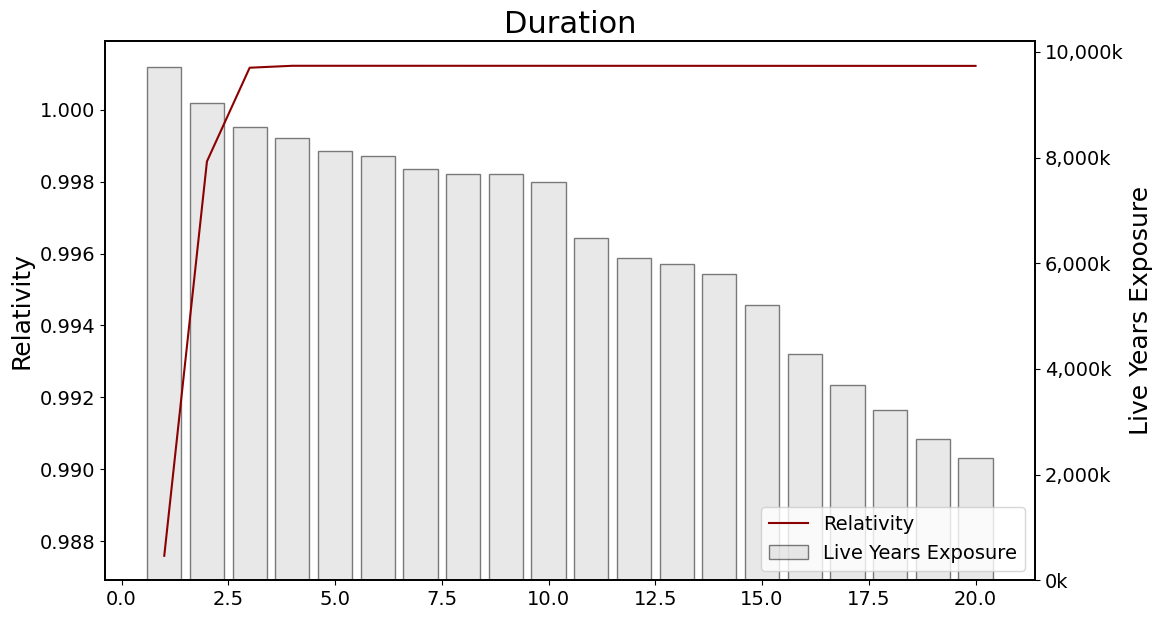

In [43]:
###################################################################
###################################################################

# Define the age variable
age_var = "Attained_Age"
rightylabel = "Live Years Exposure"

###################################################################
###################################################################

for v in single_fact_df["feature"]:

    # Get the relativity table
    rel_table = (
        num_rel_dict[v] if v in num_rel_dict.keys() else cat_rel_dict[v + "_cat_level"]
    )
    rel_table = rel_table.set_index(v)
    # Start plotting
    fig, ax = plt.subplots(1, figsize=(12, 7))
    leftylabel = "Relativity (Log-Scale)" if v == age_var else "Relativity"

    sns.lineplot(data=rel_table["relativity"], ax=ax, color="darkred", label=leftylabel)

    ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)
    ax.set_xlabel("")
    ax.set_ylabel(leftylabel, fontsize=label_fontsize)
    ax.set_title(v.replace("_ordinal", ""), fontsize=title_fontsize)

    if v == age_var:
        ax.set_yscale("log")

        # Set specific tick locations
        ax.yaxis.set_major_locator(mtick.FixedLocator([1, 10]))

        # Format labels
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: "{:g}".format(y)))

        # Add minor ticks for gridlines
        ax.yaxis.set_minor_locator(
            LogLocator(base=10, subs=np.arange(2, 10), numticks=10)
        )
        ax.tick_params(axis="y", which="minor", length=5, width=1, direction="out")

    ax.grid(False)

    ax2 = ax.twinx()
    ax2.bar(
        rel_table.index,
        rel_table[exposure],
        color="lightgray",
        alpha=0.5,
        ec="k",
        label=rightylabel,
    )
    # Format secondary y-axis ticker
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
    ax2.tick_params(axis="y", which="major", labelsize=tick_fontsize)

    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    bars, bar_labels = ax2.get_legend_handles_labels()
    ax.legend(
        lines + bars,
        labels + bar_labels,
        loc="best",
        fontsize=tick_fontsize,
        facecolor="white",
    )
    # Set secondary y-axis label
    ax2.set_ylabel(rightylabel, fontsize=label_fontsize)

    # Define order of layering
    ax.set_zorder(2)
    ax.patch.set_alpha(0)
    ax2.set_zorder(1)

### Interaction Trends

In [44]:
for var, rel in inter_rel_dict2.items(): 
    var1, var2 = var.split(" x ")
    
    rel1 = (
        cat_rel_dict[var1] if "_cat_level" in var1 else num_rel_dict[var1]
    )
    rel2 = (
        cat_rel_dict[var2] if "_cat_level" in var2 else num_rel_dict[var2]
    )
    
    inter_rel_dict2[var]["var1_rel"] = inter_rel_dict2[var][var1].map(
        rel1.set_index(var1)["relativity"].to_dict()
    )
    inter_rel_dict2[var]["var2_rel"] = inter_rel_dict2[var][var2].map(
        rel2.set_index(var2)["relativity"].to_dict()
    )
    inter_rel_dict2[var]["combined_rel"] = (
        inter_rel_dict2[var]["relativity"]
        * inter_rel_dict2[var]["var1_rel"]
        * inter_rel_dict2[var]["var2_rel"]
    )

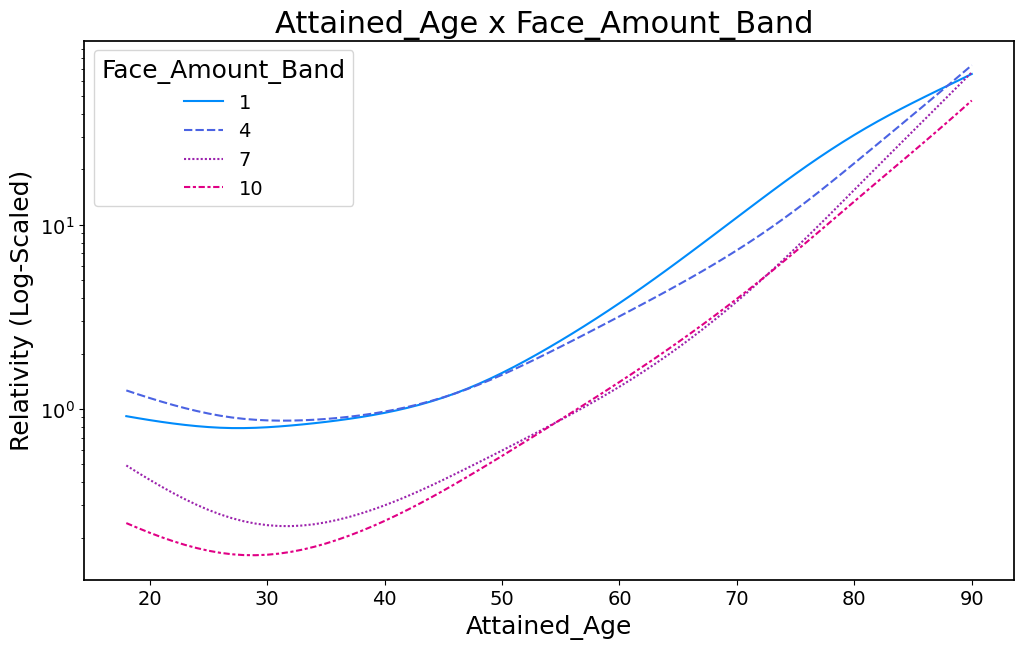

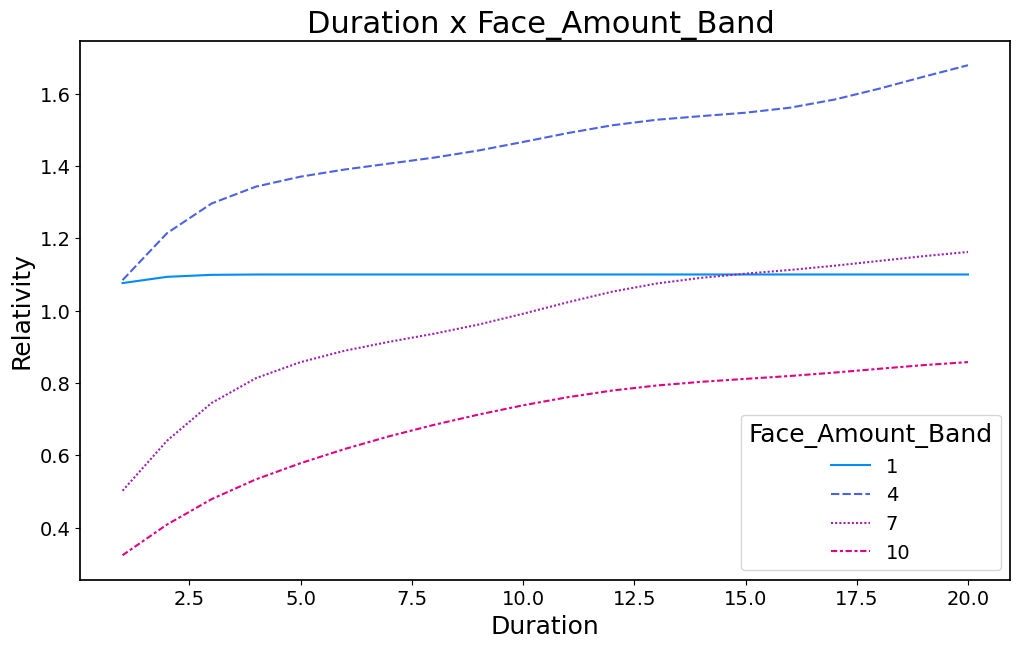

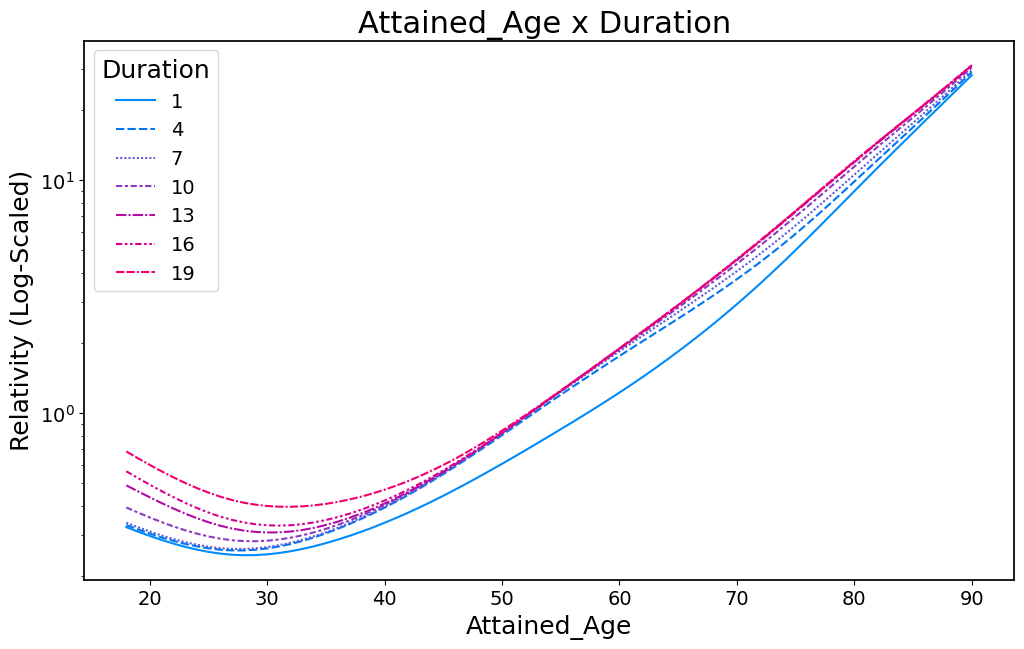

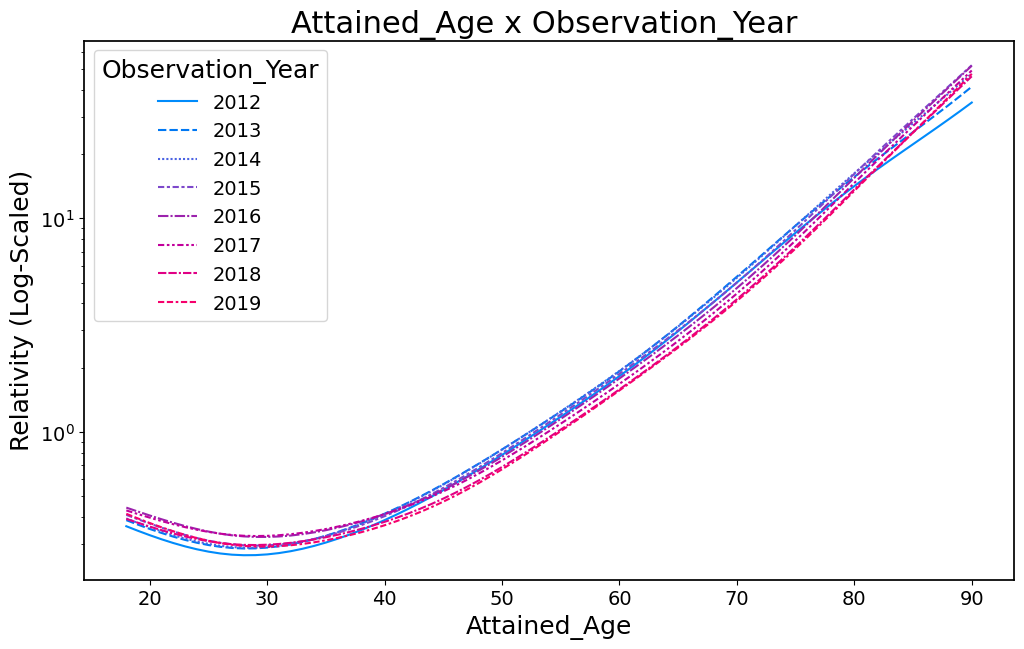

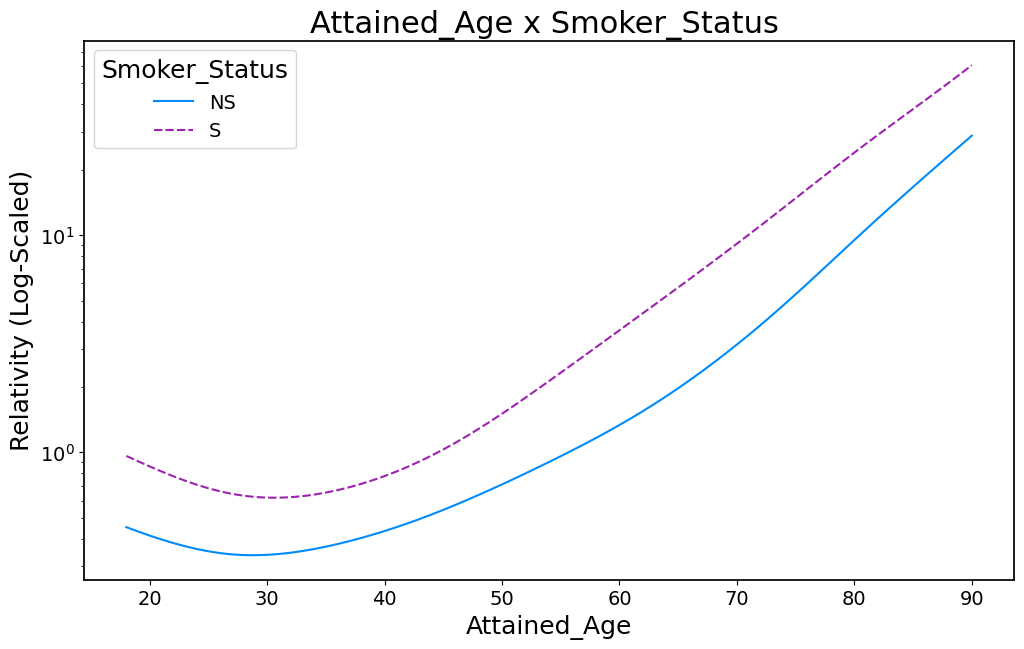

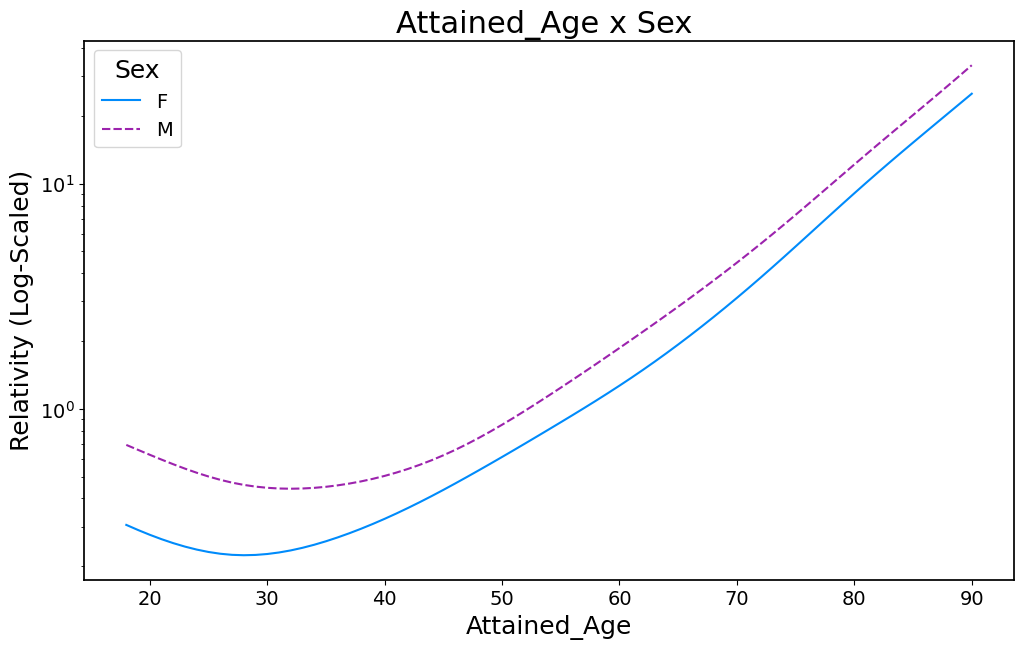

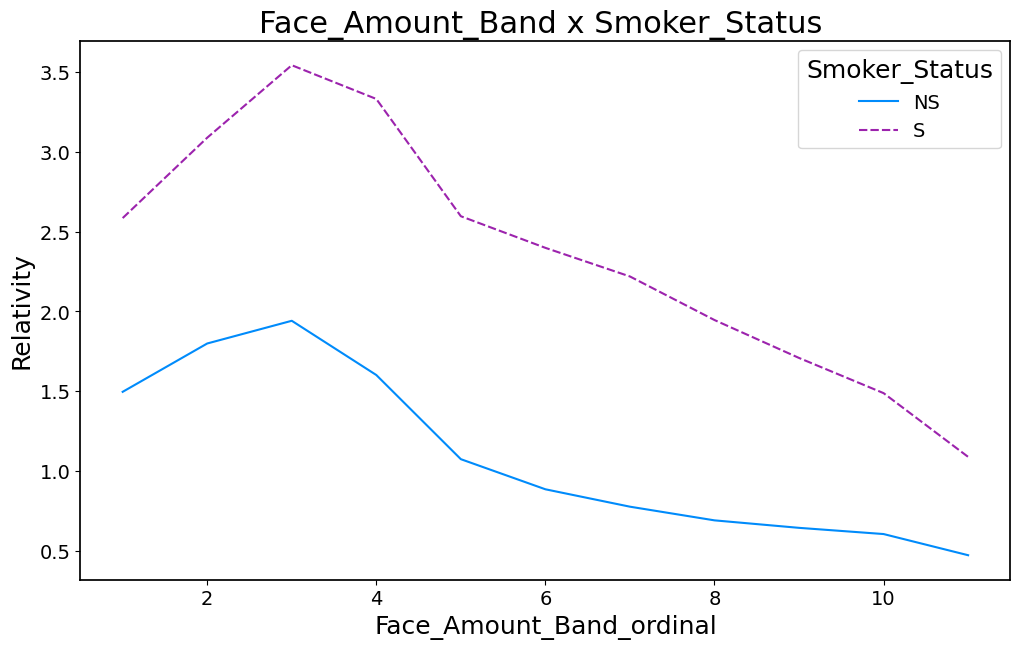

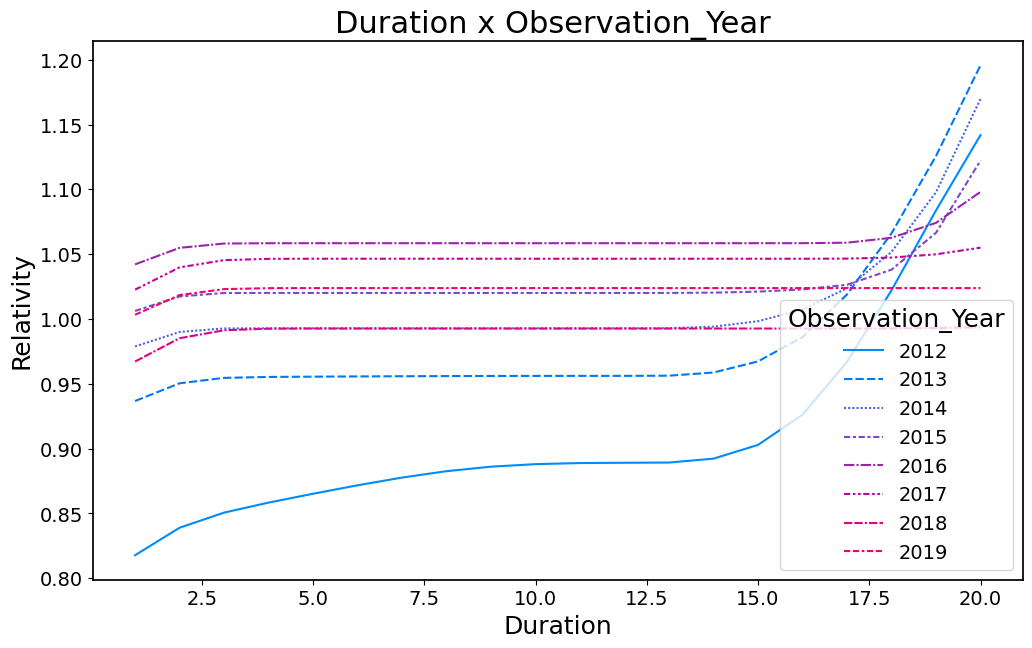

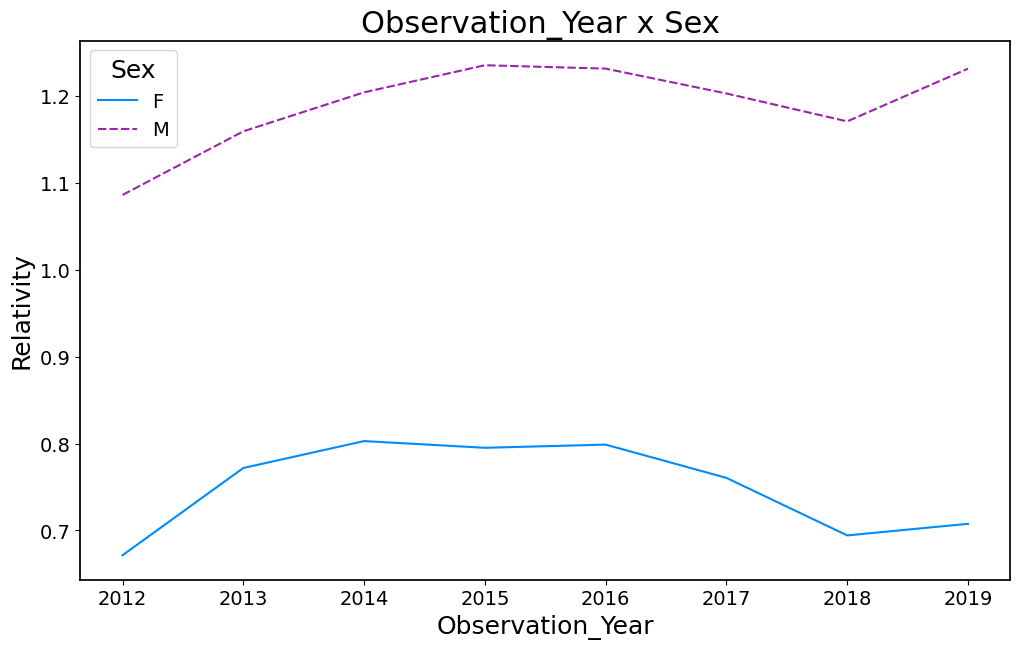

In [45]:
#################################################################
#################################################################

value_col = "combined_rel"
cmap = red_blue
age_var = "Attained_Age"
title_suffix = ""
reverse_order_list = ["Duration x Issue_Age"]

#################################################################
#################################################################

cat_feat_clean = [x.replace("_cat_level", "") for x in cat_feat]

for k in interaction_df["interaction2"]:

    v1 = k.split(" x ")[0]
    v1 += "_cat_level" if v1 in cat_feat_clean else ""
    v2 = k.split(" x ")[1]
    v2 += "_cat_level" if v2 in cat_feat_clean else ""
    v1_clean = v1.replace("_cat_level", "")
    v2_clean = v2.replace("_cat_level", "")

    v = inter_rel_dict2[v1 + " x " + v2]

    if k in reverse_order_list:
        primary_var = v2
        secondary_var = v1
        primary_var_clean = v2_clean
        secondary_var_clean = v1_clean
    else:
        primary_var = v1
        secondary_var = v2
        primary_var_clean = v1_clean
        secondary_var_clean = v2_clean

    rel_wide = v.sort_values([primary_var_clean, secondary_var_clean]).pivot(
        index=primary_var_clean, columns=secondary_var_clean, values=value_col
    )
    column_len = len(rel_wide.columns)

    if secondary_var_clean in num_rel_dict.keys():
        if secondary_var_clean == "Observation_Year":
            divisor = 1
        elif column_len <= 5:
            divisor = 1
        elif column_len <= 10:
            divisor = 2
        else:
            divisor = 3
        chosen_index = [i for i in range(column_len) if i % divisor == 0]
    else:
        chosen_index = list(range(column_len))
    num_colours = len(chosen_index)
    palette = [cmap(i / num_colours) for i in range(num_colours)]

    fig, ax = plt.subplots(1, figsize=(12, 7))
    leftylabel = "Relativity (Log-Scale)" if primary_var == age_var else "Relativity"
    plot_data = rel_wide.iloc[:, chosen_index]
    plot_data.columns = [
        c if (isinstance(c, str) or c != int(c)) else int(c) for c in plot_data.columns
    ]
    sns.lineplot(data=plot_data, ax=ax, palette=palette)

    if primary_var == age_var:
        ax.set_yscale("log")
        leftylabel = "Relativity (Log-Scaled)"
    else:
        leftylabel = "Relativity"

    ax.set_xlabel(primary_var_clean, fontsize=label_fontsize)
    ax.set_ylabel(leftylabel, fontsize=label_fontsize)

    ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)

    ax.set_title(
        f"{primary_var_clean.replace("_ordinal", "")} x {secondary_var_clean.replace("_ordinal", "")} {title_suffix}",
        fontsize=title_fontsize,
    )

    ax.legend(
        facecolor="white",
        fontsize=tick_fontsize,
        title=secondary_var_clean.replace("_ordinal", ""),
        title_fontsize=label_fontsize,
    )
    ax.grid(False)
    ax.set_facecolor("white")

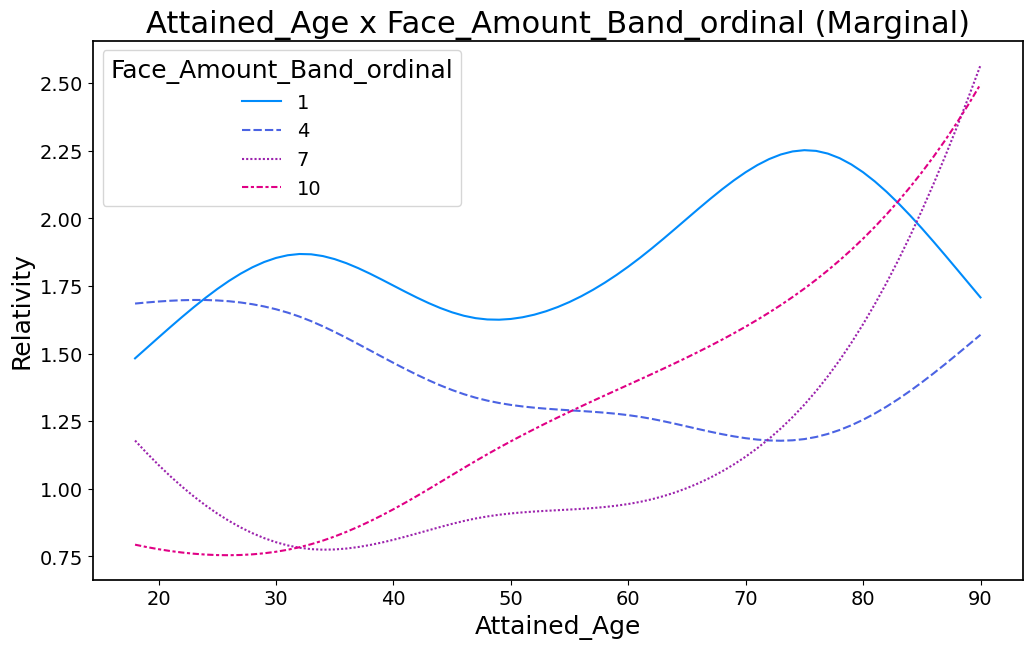

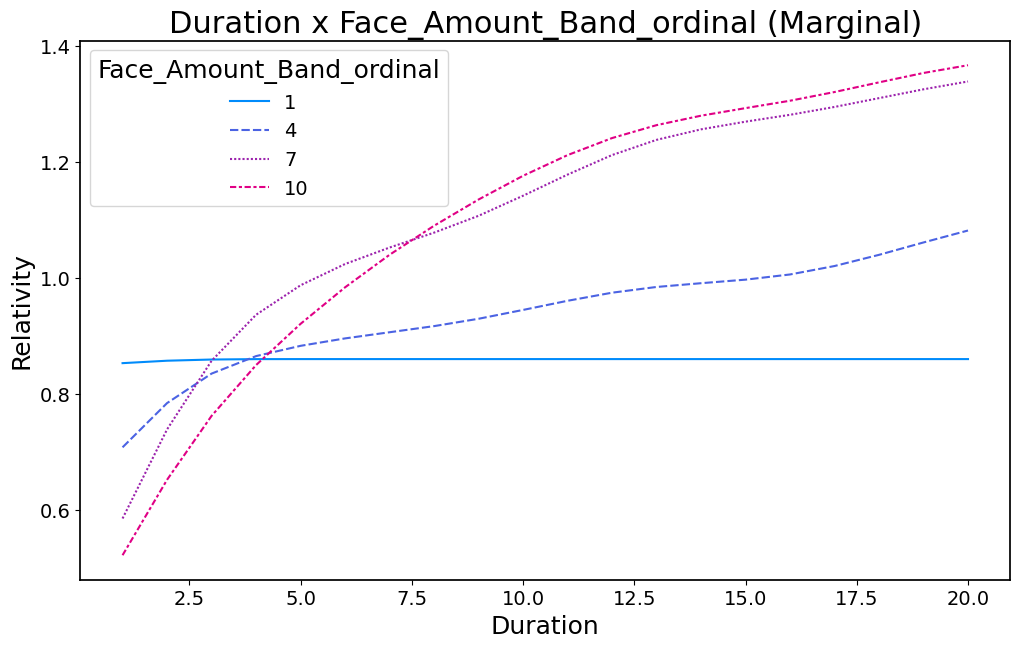

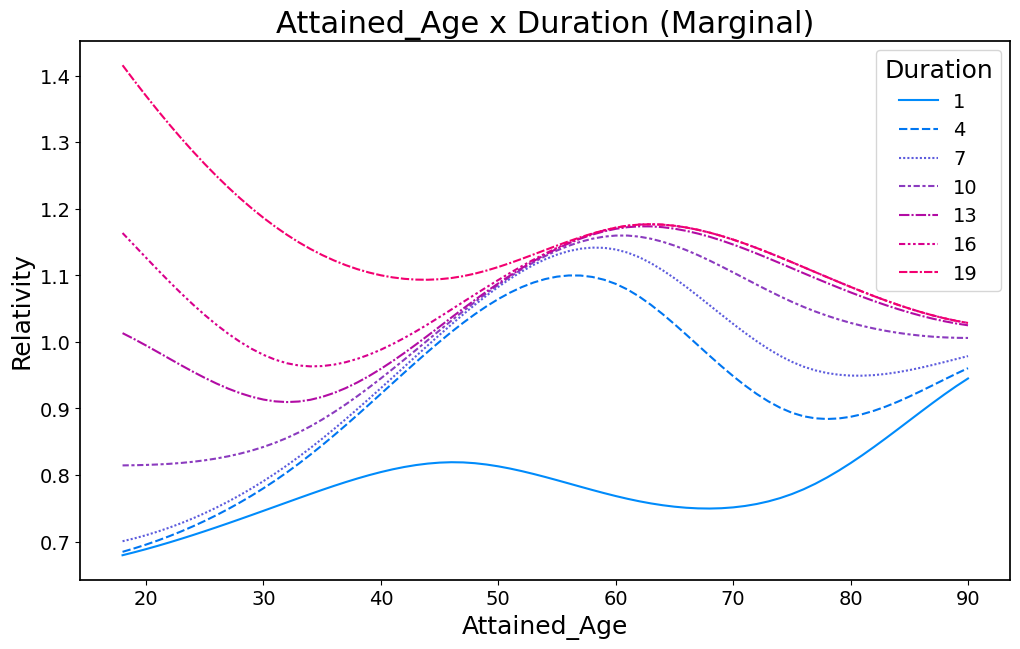

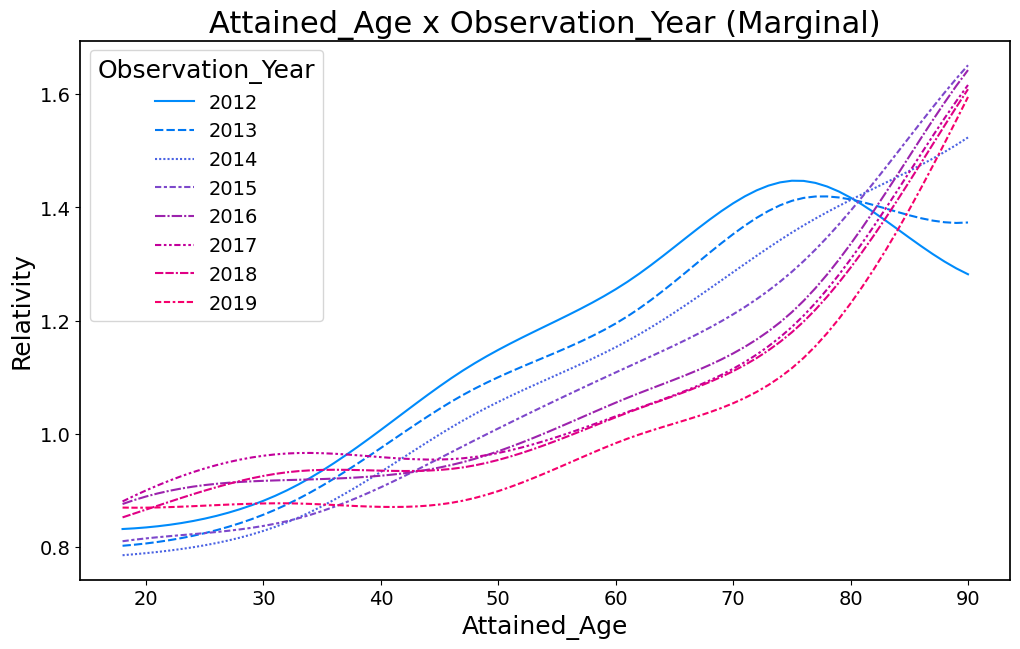

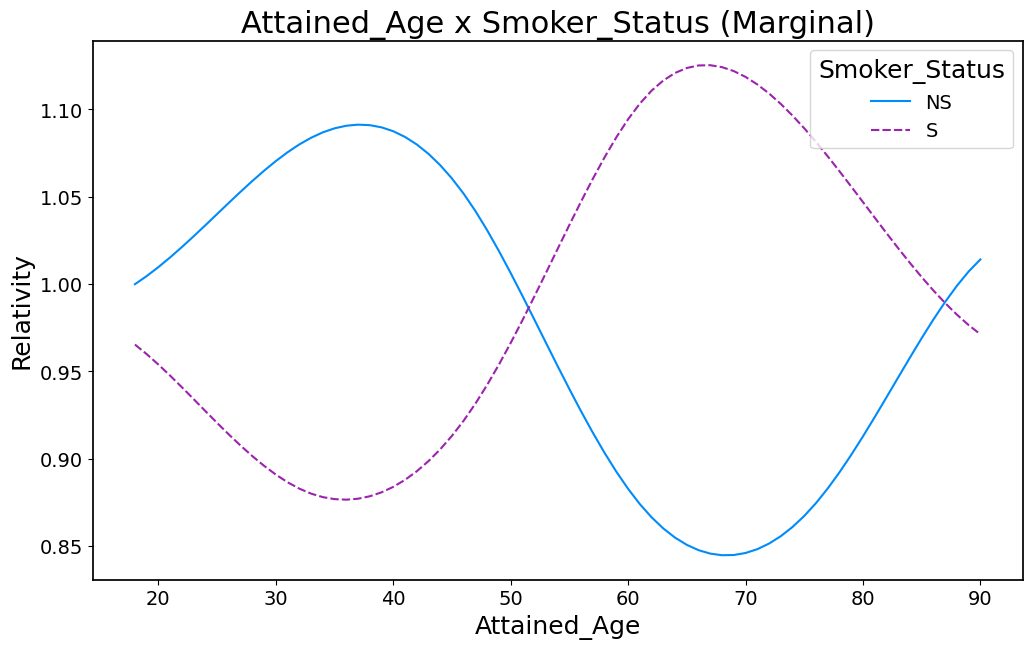

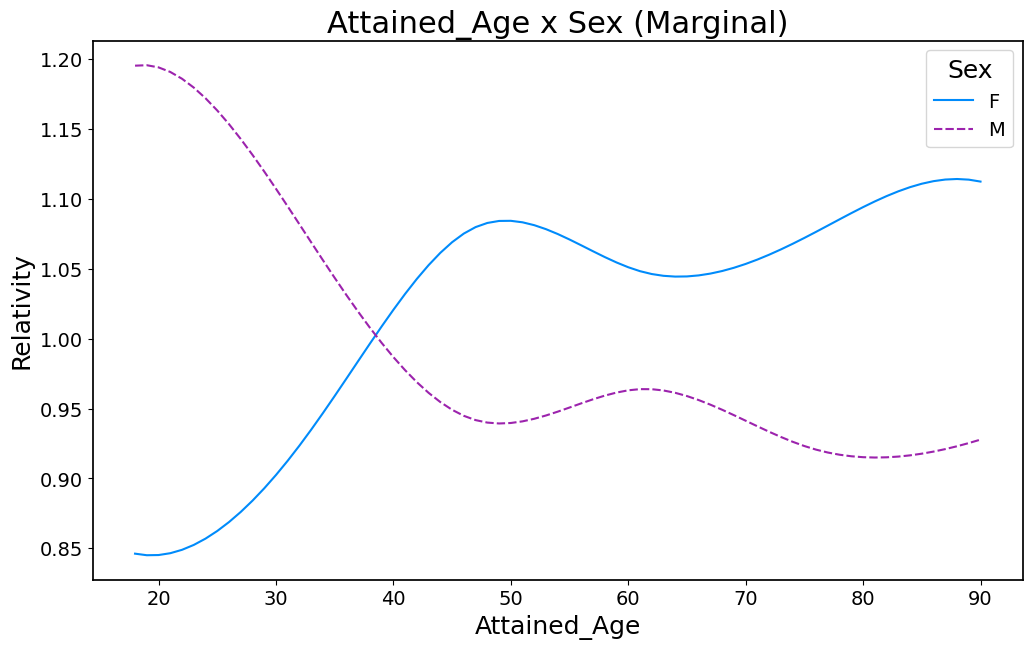

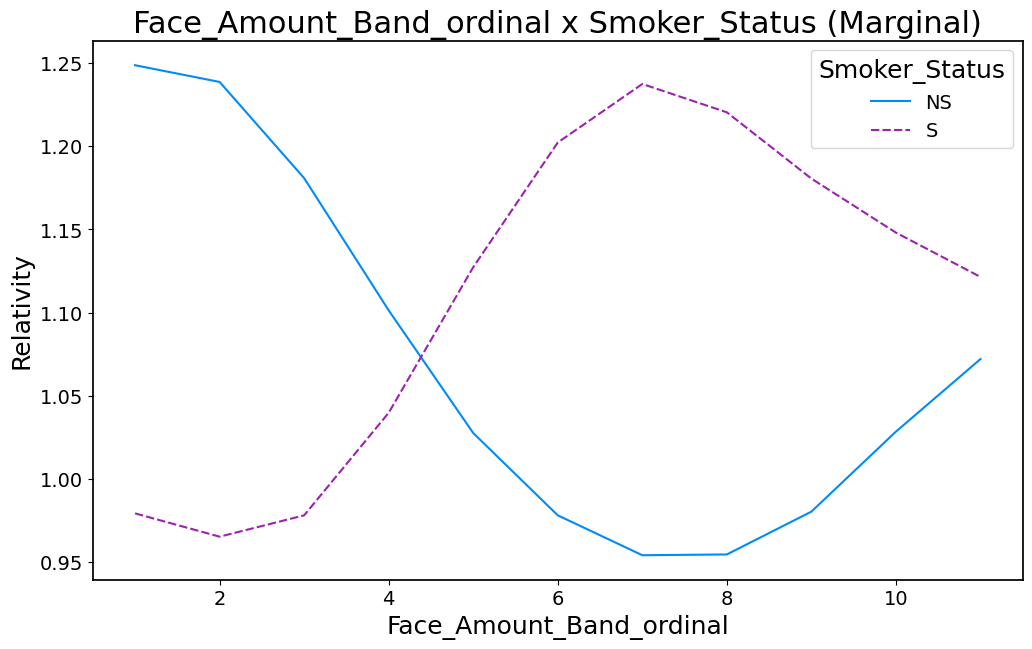

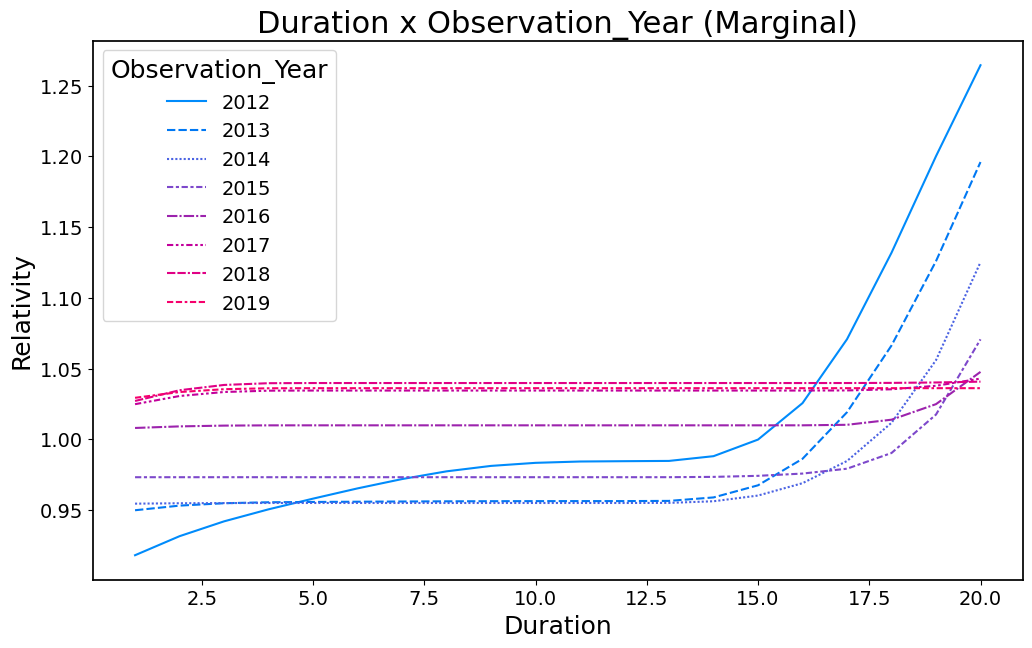

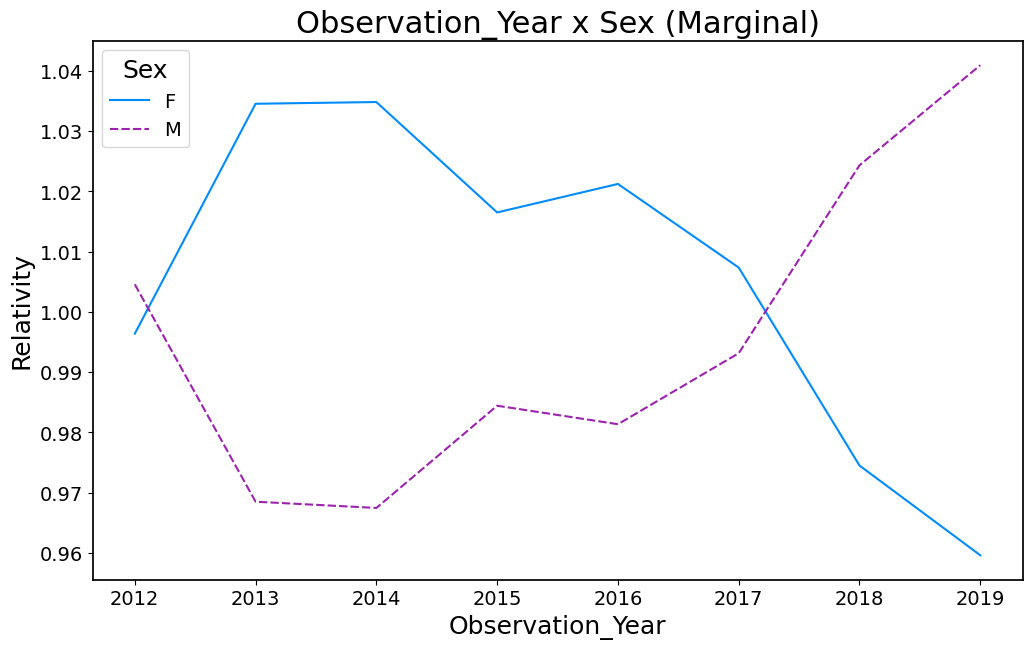

In [46]:
#################################################################
#################################################################

value_col = "relativity"
cmap = red_blue
title_suffix = "(Marginal)"

#################################################################
#################################################################

for k in interaction_df["interaction2"]:

    v1 = k.split(" x ")[0]
    v1 += "_cat_level" if v1 in cat_feat_clean else ""
    v2 = k.split(" x ")[1]
    v2 += "_cat_level" if v2 in cat_feat_clean else ""
    v1_clean = v1.replace("_cat_level", "")
    v2_clean = v2.replace("_cat_level", "")

    v = inter_rel_dict2[v1 + " x " + v2]


    if k in reverse_order_list:
        primary_var = v2
        secondary_var = v1
        primary_var_clean = v2_clean
        secondary_var_clean = v1_clean
    else:
        primary_var = v1
        secondary_var = v2
        primary_var_clean = v1_clean
        secondary_var_clean = v2_clean

    rel_wide = v.sort_values([primary_var_clean, secondary_var_clean]).pivot(
        index=primary_var_clean, columns=secondary_var_clean, values=value_col
    )
    column_len = len(rel_wide.columns)

    if secondary_var_clean in num_rel_dict.keys():
        if secondary_var_clean == "Observation_Year":
            divisor = 1
        elif column_len <= 5:
            divisor = 1
        elif column_len <= 10:
            divisor = 2
        else:
            divisor = 3
        chosen_index = [i for i in range(column_len) if i % divisor == 0]
    else:
        chosen_index = list(range(column_len))
    num_colours = len(chosen_index)
    palette = [cmap(i / num_colours) for i in range(num_colours)]

    fig, ax = plt.subplots(1, figsize=(12, 7))
    leftylabel = "Relativity (Log-Scale)" if primary_var == age_var else "Relativity"
    plot_data = rel_wide.iloc[:, chosen_index]
    plot_data.columns = [
        c if (isinstance(c, str) or c != int(c)) else int(c) for c in plot_data.columns
    ]
    sns.lineplot(data=plot_data, ax=ax, palette=palette)

    leftylabel = "Relativity"

    ax.set_xlabel(primary_var_clean, fontsize=label_fontsize)
    ax.set_ylabel(leftylabel, fontsize=label_fontsize)

    ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)

    ax.set_title(
        f"{primary_var_clean} x {secondary_var_clean} {title_suffix}",
        fontsize=title_fontsize,
    )

    ax.legend(
        facecolor="white",
        fontsize=tick_fontsize,
        title=secondary_var_clean,
        title_fontsize=label_fontsize,
    )
    ax.grid(False)
    ax.set_facecolor("white")

### Actual vs Expected Analysis on Holdout

In [47]:
##################################################################
##################################################################

key_features = [x.replace("_ordinal", "") for x in single_fact_df["feature"]]

##################################################################
##################################################################

# Initialise an empty dict for holding the grouped by dataframes
risk_agg_dict = {}

for v in key_features:
    # Perform risk aggregations by individual features
    df_gb = utils.risk_agg(
        ypred_test_df.join(model_data[key_features]),
        v,
        exposure,
        act_death,
        expected_death_count_mi=exp_death_mi,
        gam_sf_death_count="ypred_death_count",
        gam_final_death_count="ypred_final_death_count",
    )
    # We're doing Actual vs Expected analysis
    df_gb["expected_death_rate_mi"] = (
        df_gb["actual_death_rate"] / df_gb["expected_death_rate_mi"]
    )
    df_gb["gam_sf_death_rate"] = (
        df_gb["actual_death_rate"] / df_gb["gam_sf_death_rate"]
    )
    df_gb["gam_final_death_rate"] = (
        df_gb["actual_death_rate"] / df_gb["gam_final_death_rate"]
    )

    risk_agg_dict[v] = df_gb

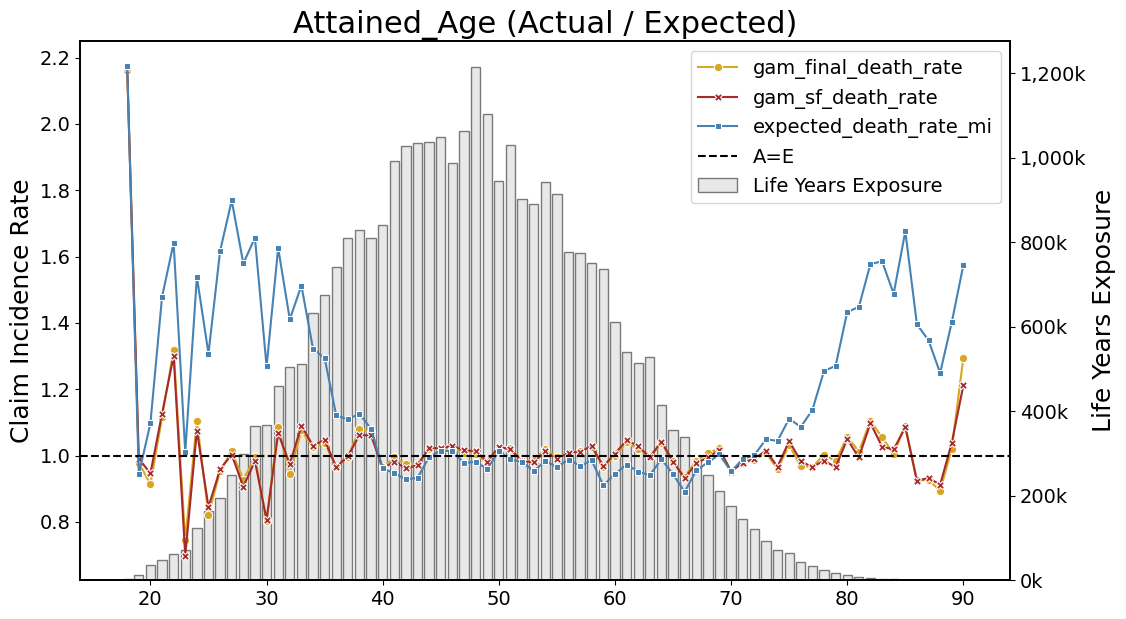

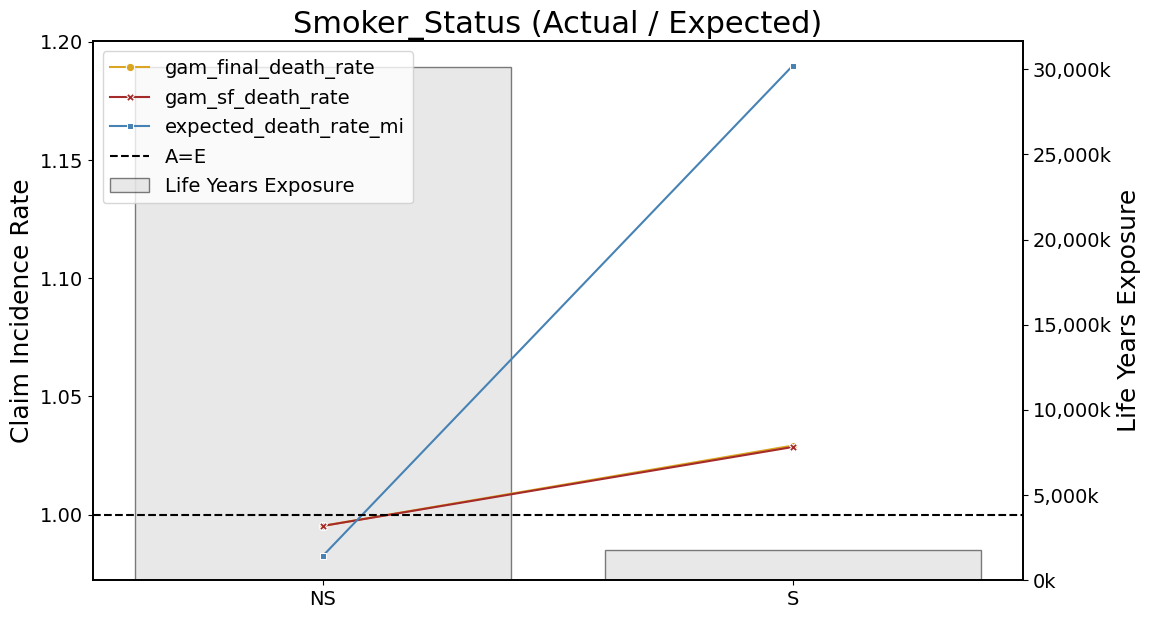

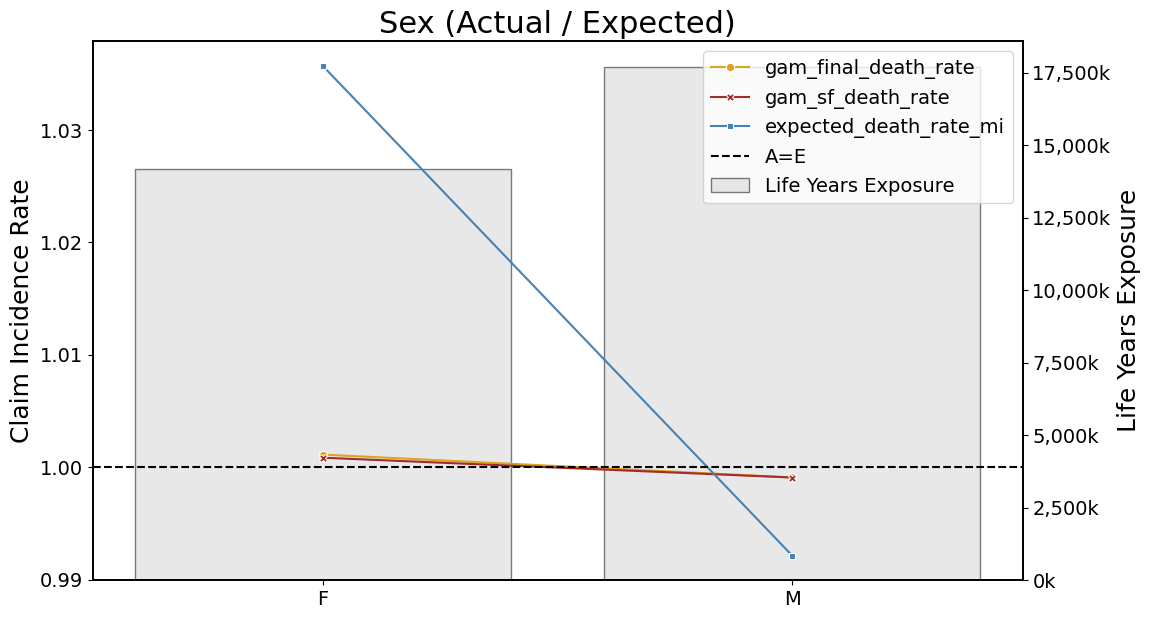

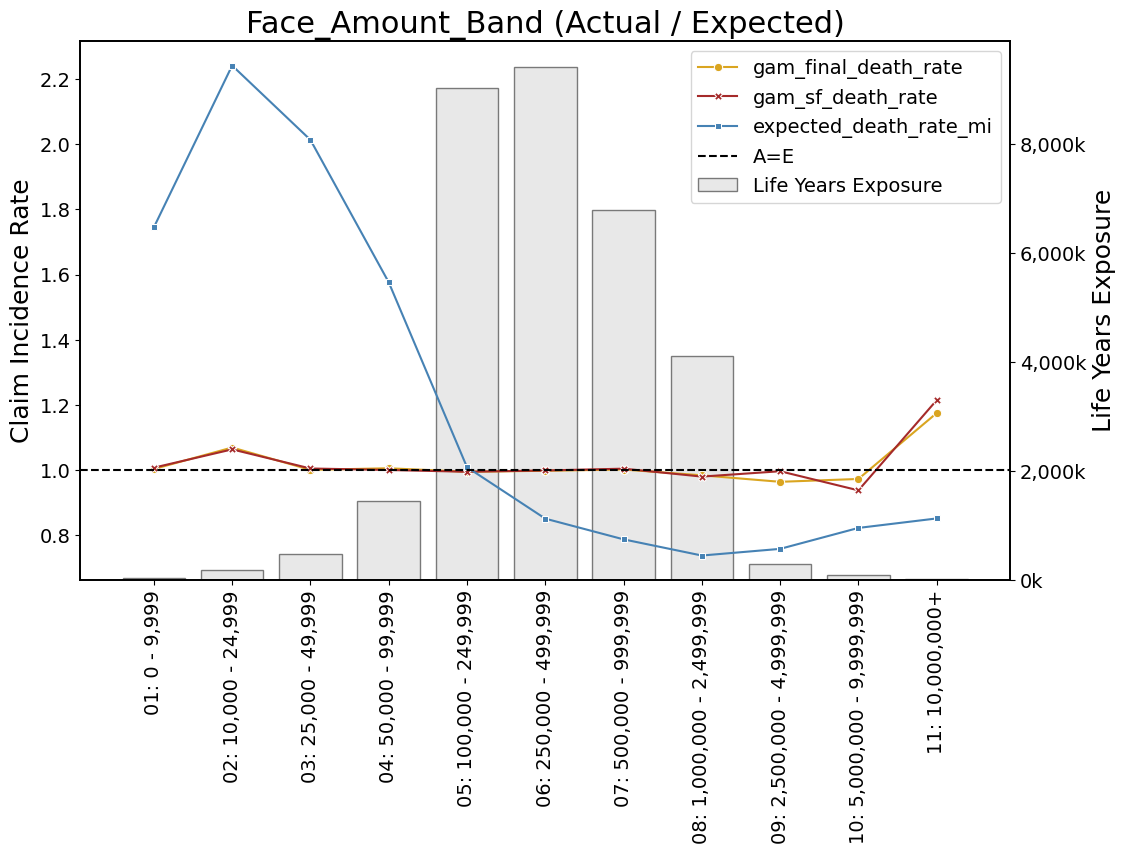

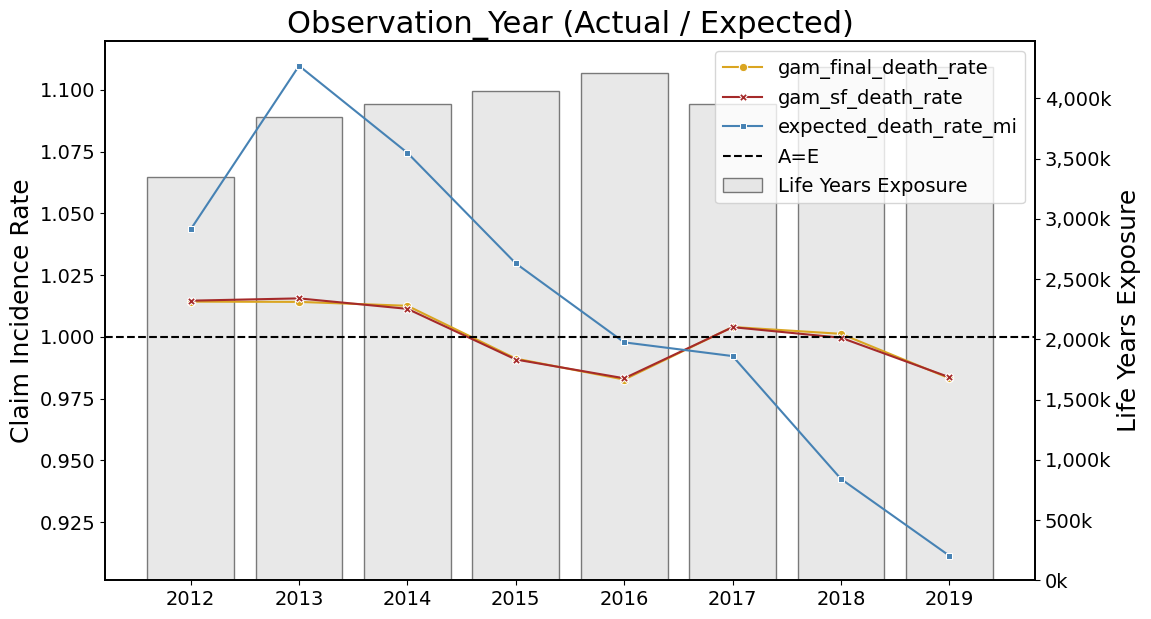

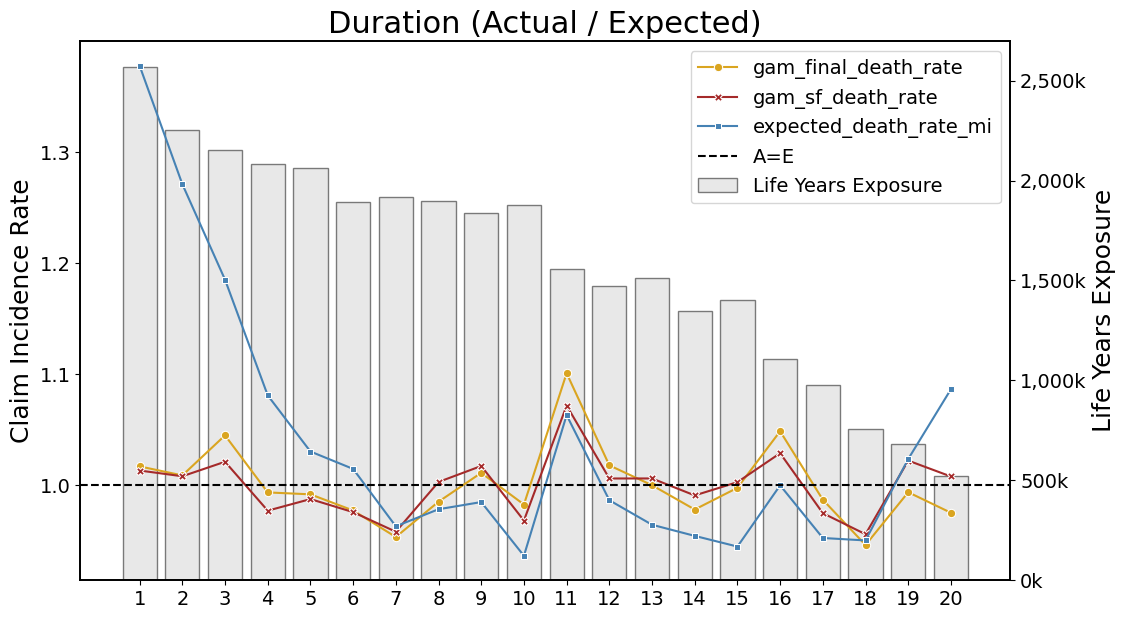

In [48]:
##############################################################################################
##############################################################################################

y1_label = "Claim Incidence Rate"
y2_label = "Life Years Exposure"

##############################################################################################
##############################################################################################

for var in key_features:

    fig, ax = plt.subplots(1, figsize=(12, 7))
    # Plot incidence rates
    sns.lineplot(
        data=risk_agg_dict[var].loc[
            :,
            [
                "gam_final_death_rate",
                "gam_sf_death_rate",
                "expected_death_rate_mi",
            ],
        ],
        ax=ax,
        markers=True,
        dashes=False,
        palette=["#DAA520", "#A52A2A", "#4682B4"],
    )
    ax.axhline(y=1, color="black", linestyle="--", label="A=E")

    # Set title and x and y axes labels and fontsize
    ax.set_ylabel(y1_label, fontsize=label_fontsize)
    ax.set_xlabel("")
    ax.set_title(var + " (Actual / Expected)", fontsize=title_fontsize)
    ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)

    # Fix the xticker labels if there are decimal places in xtickers when variable should be integers
    if not isinstance(risk_agg_dict[var].index[0], str):
        index_has_decimals = any(val % 1 != 0 for val in risk_agg_dict[var].index)
        ticks_have_decimals = any(tick % 1 != 0 for tick in ax.get_xticks())

        if not index_has_decimals and ticks_have_decimals:
            ax.set_xticks(risk_agg_dict[var].index)
            ax.set_xticklabels(risk_agg_dict[var].index)

    # Format x-axis tickers
    ax.tick_params(
        axis="x",
        rotation=(
            90
            if isinstance(risk_agg_dict[var].index[0], str)
            and len(risk_agg_dict[var].index[0]) > 4
            else 0
        ),
    )

    # Create secondary y-axis for exposures
    ax2 = ax.twinx()
    ax2.bar(
        risk_agg_dict[var].index,
        risk_agg_dict[var][exposure],
        color="lightgray",
        alpha=0.5,
        ec="k",
        label=y2_label,
    )

    # Format secondary y-axis ticker
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
    ax2.tick_params(axis="y", which="major", labelsize=tick_fontsize)

    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    bars, bar_labels = ax2.get_legend_handles_labels()
    ax.legend(
        lines + bars,
        labels + bar_labels,
        loc="best",
        fontsize=tick_fontsize,
        facecolor="white",
    )

    # Set secondary y-axis label
    ax2.set_ylabel(y2_label, fontsize=label_fontsize)

    # Define order of layering
    ax.set_zorder(2)
    ax.patch.set_alpha(0)
    ax2.set_zorder(1)

## Save down all model predictions for comparisons

In [49]:
# Define a dataframe that contains predictions, target and weight
ypred_train = gam_final.predict(X_train)

ypred_train_df = pd.DataFrame(
    ypred_train, columns=["ypred_final_death_rate"], index=X_train.index
)
ypred_train_df = (
    ypred_train_df
    .join(w_train)
)
ypred_train_df["ypred_final_death_count"] = (
    ypred_train_df["ypred_final_death_rate"] * ypred_train_df[exposure]
)
ypred_train_df

,ypred_final_death_rate,Policies_Exposed,ypred_final_death_count
unique_id,,,
2,0.001450,1031.760315,1.496470
3,0.001280,327.323694,0.419056
4,0.001280,458.157228,0.586555
5,0.001151,94.146768,0.108337
6,0.001151,172.602287,0.198618
...,...,...,...
612760,0.065138,0.882192,0.057465
612761,0.062580,0.213699,0.013373
612762,0.078746,0.512329,0.040344


In [50]:
ypred_df = pd.concat(
    [
        ypred_train_df[["ypred_final_death_count", "ypred_final_death_rate"]],
        ypred_test_df[["ypred_final_death_count", "ypred_final_death_rate"]],
    ]
).sort_index()
ypred_df

,ypred_final_death_count,ypred_final_death_rate
unique_id,,
0,2.811542,0.001818
1,1.148945,0.001450
2,1.496470,0.001450
3,0.419056,0.001280
4,0.586555,0.001280
...,...,...
612760,0.057465,0.065138
612761,0.013373,0.062580
612762,0.040344,0.078746


In [51]:
ypred_df.join(ypred_xgb_df).join(
    ypred_sf_df[["ypred_death_rate", "ypred_death_count"]]
).to_parquet(final_gam_pred_file)